# SkillBridge: Explainable Skills-to-Role Matching

SkillBridge is a data project about occupations and skills.

People have different knowledge and skills. Occupations also need different
knowledge and skills. Comparing these profiles by hand can take a long time.
It can also be difficult to explain why one occupation is a better match than
another.

This notebook starts with the ESCO data and builds the analysis step by step.
Every result is linked to a clear question.

the multilingual classification system of **European Skills, Competences, Qualifications and Occupations**

## Project goal

The goal is to prepare a clear and explainable skills-to-role matching system.
The future system should show:

- which concepts a person and an occupation share;
- which important concepts are missing;
- how similar two profiles are;


The system should support a human decision. It should not automatically hire
or reject a person.

## Main research question

> **How can ESCO data be prepared and studied to support an explainable
> skills-to-role matching system?**

To answer this question, we first need to understand the data. We then compare
data and AI occupations. Finally, we test one pattern in the selected
occupations.

## Data source

This project uses the English CSV files from **ESCO v1.2.1**. ESCO is the
European classification of skills, competences, qualifications, and
occupations.

The three source files are:

- `occupations_en.csv` — information about occupations;
- `skills_en.csv` — information about knowledge, skills, and competences;
- `occupationSkillRelations_en.csv` — links between occupations and concepts.

Official source: [Download ESCO](https://esco.ec.europa.eu/en/use-esco/download)

## Notebook map

- **Part 1 — Understand and prepare the data**  
  Load, inspect, clean, and store the ESCO data in SQLite.

- **Part 2 — Compare data and AI occupations**  
  Compare concept counts, shared concepts, and occupation similarity.

- **Part 3 — Test a pattern**  
  Explore whether the selected occupations usually contain more
  skill/competence concepts than knowledge concepts.

Each Part can be collapsed in VS Code. Every subsection has its own Markdown
heading so the notebook stays easy to navigate.

## Responsible use

ESCO is an occupation classification. It is not a test of a person's value or
ability. A listed concept may be important in one job but less important in
another job with the same title.

For this reason, the results must not be used as an automatic hiring or
rejection rule. Real recruitment should also consider experience, education,
learning ability, context, and human judgement.

# Part 1 — Understand and Prepare the Data

Before we can compare occupations, we must know what the data contains and
whether it is reliable enough for analysis.

In this Part, we move from three large source files to three clean tables that
can be queried with SQL.

## Part 1 contents

1. **1.1** Load and check the source data  
2. **1.2** Keep the useful columns  
3. **1.3** Clean and check the data  
4. **1.4** Create the SQL database  
5. **1.5** Explore the main categories  
6. **1.6** Explore one occupation  
7. **1.7** Compare essential and optional concepts  
8. **1.8** Answer the Part 1 question

## 1.1 Load and Check the Source Data

We begin by loading the three ESCO files. The files are kept unchanged. This
is important because we may need to return to the original data later.

After loading, we check that every dataset has records. We also view its size
and first three rows. This gives us a first picture of the data structure.

In [1]:
# Import pandas and define the locations of the three source files

from pathlib import Path
import pandas as pd


# The CSV files are in the same folder as this notebook
DATA_PATH = Path(".")

occupations = pd.read_csv(
    DATA_PATH / "occupations_en.csv",
    low_memory=False
)

skills = pd.read_csv(
    DATA_PATH / "skills_en.csv",
    low_memory=False
)

relations = pd.read_csv(
    DATA_PATH / "occupationSkillRelations_en.csv",
    low_memory=False
)

In [2]:
# Check that none of the three source datasets is empty

assert not occupations.empty, "The occupations dataset is empty."
assert not skills.empty, "The skills dataset is empty."
assert not relations.empty, "The relations dataset is empty."

print("All datasets were loaded successfully.")

All datasets were loaded successfully.


In [3]:
# Show the size of each source dataset

dataset_summary = pd.DataFrame({
    "dataset": ["occupations", "skills", "relations"],
    "rows": [
        occupations.shape[0],
        skills.shape[0],
        relations.shape[0]
    ],
    "columns": [
        occupations.shape[1],
        skills.shape[1],
        relations.shape[1]
    ]
})

display(dataset_summary)

,dataset,rows,columns
0,occupations,3043,15
1,skills,13960,13
2,relations,126051,6


In [4]:
# Preview the first three rows of each source dataset

display(occupations.head(3))
display(skills.head(3))
display(relations.head(3))

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,naceCode
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,director of technical arts\ntechnical supervis...,NaN,released,2024-01-25T11:28:50.295Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Technical directors realise the artistic visio...,2654.1.7,http://data.europa.eu/ux2/nace2.1/9031
1,Occupation,http://data.europa.eu/esco/occupation/000e93a3...,8121,metal drawing machine operator,wire drawer\nforming machine operative\ndraw m...,NaN,released,2024-01-23T10:09:32.099Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Metal drawing machine operators set up and ope...,8121.4,http://data.europa.eu/ux2/nace2.1/242
2,Occupation,http://data.europa.eu/esco/occupation/0019b951...,7543,precision device inspector,precision device quality control supervisor\np...,NaN,released,2024-01-25T15:00:12.188Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Precision device inspectors make sure precisio...,7543.10.3,http://data.europa.eu/ux2/nace2.1/2651


,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,manage musical staff,manage music staff\ncoordinate duties of music...,NaN,released,2023-11-30T15:53:37.136Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Assign and manage staff tasks in areas such as...
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,supervise correctional procedures,manage prison procedures\nmonitor correctional...,NaN,released,2023-11-30T15:04:00.689Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Supervise the operations of a correctional fac...
2,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/000709ed-2be5...,skill/competence,sector-specific,apply anti-oppressive practices,make use of anti-oppressive practices\nuse ant...,NaN,released,2023-11-28T10:45:53.54Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Identify oppression in societies, economies, c..."


,occupationUri,occupationLabel,relationType,skillType,skillUri,skillLabel
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,knowledge,http://data.europa.eu/esco/skill/fed5b267-73fa...,theatre techniques
1,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/05bc7677-5a64...,organise rehearsals
2,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/271a36a0-bc7a...,write risk assessment on performing arts produ...


### What did we learn?

All three files loaded correctly:

- 3,043 occupation rows;
- 13,960 skill and knowledge rows;
- 126,051 occupation–concept relations.

The relation file is the largest because one occupation can be connected to
many concepts, and one concept can be connected to many occupations.

## 1.2 Keep the Useful Columns

The source files contain many columns, but this project does not need all of
them. Keeping only useful columns makes the data easier to read and reduces
mistakes.

We create new working tables and leave the source tables unchanged. We also
rename columns to `snake_case`. The same names can then be used in Python,
SQL, and later in Power BI.

In [5]:
# Keep and rename the useful occupation columns

occupations_work = occupations[
    [
        "conceptUri",
        "iscoGroup",
        "preferredLabel",
        "status",
        "description"
    ]
].copy()

occupations_work = occupations_work.rename(columns={
    "conceptUri": "occupation_uri",
    "iscoGroup": "isco_group",
    "preferredLabel": "occupation_name",
    "description": "occupation_description"
})

In [6]:
# Keep and rename the useful skill columns

skills_work = skills[
    [
        "conceptUri",
        "skillType",
        "reuseLevel",
        "preferredLabel",
        "status",
        "description"
    ]
].copy()

skills_work = skills_work.rename(columns={
    "conceptUri": "skill_uri",
    "skillType": "skill_type",
    "reuseLevel": "reuse_level",
    "preferredLabel": "skill_name",
    "description": "skill_description"
})

In [7]:
# Keep and rename the useful relation columns

relations_work = relations[
    [
        "occupationUri",
        "occupationLabel",
        "relationType",
        "skillType",
        "skillUri",
        "skillLabel"
    ]
].copy()

relations_work = relations_work.rename(columns={
    "occupationUri": "occupation_uri",
    "occupationLabel": "occupation_name",
    "relationType": "relation_type",
    "skillType": "skill_type",
    "skillUri": "skill_uri",
    "skillLabel": "skill_name"
})

In [8]:
# Preview the three smaller working datasets

display(occupations_work.head(3))
display(skills_work.head(3))
display(relations_work.head(3))

,occupation_uri,isco_group,occupation_name,status,occupation_description
0,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,released,Technical directors realise the artistic visio...
1,http://data.europa.eu/esco/occupation/000e93a3...,8121,metal drawing machine operator,released,Metal drawing machine operators set up and ope...
2,http://data.europa.eu/esco/occupation/0019b951...,7543,precision device inspector,released,Precision device inspectors make sure precisio...


,skill_uri,skill_type,reuse_level,skill_name,status,skill_description
0,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,manage musical staff,released,Assign and manage staff tasks in areas such as...
1,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,supervise correctional procedures,released,Supervise the operations of a correctional fac...
2,http://data.europa.eu/esco/skill/000709ed-2be5...,skill/competence,sector-specific,apply anti-oppressive practices,released,"Identify oppression in societies, economies, c..."


,occupation_uri,occupation_name,relation_type,skill_type,skill_uri,skill_name
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,knowledge,http://data.europa.eu/esco/skill/fed5b267-73fa...,theatre techniques
1,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/05bc7677-5a64...,organise rehearsals
2,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/271a36a0-bc7a...,write risk assessment on performing arts produ...


In [9]:
# Show the size of the working datasets

print("Occupations:", occupations_work.shape)
print("Skills:", skills_work.shape)
print("Relations:", relations_work.shape)

Occupations: (3043, 5)
Skills: (13960, 6)
Relations: (126051, 6)


### Column guide

**Occupations table**

| Column | Simple meaning |
|---|---|
| `occupation_uri` | Unique ESCO ID for an occupation |
| `isco_group` | International occupation group code |
| `occupation_name` | Name of the occupation |
| `status` | Whether the ESCO record is published for use |
| `occupation_description` | Explanation of the occupation |

**Skills table**

| Column | Simple meaning |
|---|---|
| `skill_uri` | Unique ESCO ID for a concept |
| `skill_type` | `knowledge` or `skill/competence` |
| `reuse_level` | How widely the concept can be used |
| `skill_name` | Name of the concept |
| `status` | Whether the ESCO record is published for use |
| `skill_description` | Explanation of the concept |

**Relations table**

| Column | Simple meaning |
|---|---|
| `occupation_uri` | ID of the occupation |
| `occupation_name` | Name of the occupation |
| `relation_type` | `essential` or `optional` |
| `skill_type` | Type of concept |
| `skill_uri` | ID of the concept |
| `skill_name` | Name of the concept |

The value `released` does **not** describe a job vacancy. It means that the
record was published in this ESCO version.

### Why do we keep the URI columns?

A name can change or appear in more than one form. A URI is a stable and
unique ID. We therefore use `occupation_uri` and `skill_uri` when we connect
tables or compare concepts.

This is safer than joining tables only by names.

## 1.3 Clean and Check the Data

Clean data is needed before SQL analysis. We check missing values first. We
then remove duplicate IDs and fill a small number of missing categories.

We do not delete a useful concept only because its category is missing. We use
the label `unknown` so the missing category stays visible.

### Check the data before cleaning

This first check counts all missing values in the smaller working tables. It
shows where cleaning is needed before we continue.

In [10]:
# Count rows and missing values before cleaning

data_summary = pd.DataFrame({
    "dataset": ["occupations", "skills", "relations"],
    "rows": [
        len(occupations_work),
        len(skills_work),
        len(relations_work)
    ],
    "missing_values": [
        occupations_work.isna().sum().sum(),
        skills_work.isna().sum().sum(),
        relations_work.isna().sum().sum()
    ]
})

display(data_summary)

,dataset,rows,missing_values
0,occupations,3043,0
1,skills,13960,10
2,relations,126051,59


### Cleaning choices

We make four simple cleaning choices:

1. Keep one row for each occupation URI.
2. Keep one row for each skill URI.
3. Remove repeated occupation–skill relations.
4. Fill a missing skill type from the skills table when possible. If it is
   still missing, use `unknown`.

In [11]:
# Remove duplicate occupation, skill, and relation records

occupations_clean = occupations_work.drop_duplicates(
    subset="occupation_uri"
).copy()

skills_clean = skills_work.drop_duplicates(
    subset="skill_uri"
).copy()

relations_clean = relations_work.drop_duplicates(
    subset=["occupation_uri", "skill_uri", "relation_type"]
).copy()

In [12]:
# Replace missing skill categories with the label unknown

skills_clean["skill_type"] = skills_clean["skill_type"].fillna("unknown")

skills_clean["reuse_level"] = skills_clean["reuse_level"].fillna("unknown")

In [13]:
# Fill missing relation skill types by using the skills dataset

skill_type_lookup = skills_clean.set_index("skill_uri")["skill_type"]

relations_clean["skill_type"] = relations_clean["skill_type"].fillna(
    relations_clean["skill_uri"].map(skill_type_lookup)
)

relations_clean["skill_type"] = relations_clean["skill_type"].fillna("unknown")

In [14]:
# Check rows and missing values after cleaning

clean_data_summary = pd.DataFrame({
    "dataset": ["occupations", "skills", "relations"],
    "rows": [
        len(occupations_clean),
        len(skills_clean),
        len(relations_clean)
    ],
    "missing_values": [
        occupations_clean.isna().sum().sum(),
        skills_clean.isna().sum().sum(),
        relations_clean.isna().sum().sum()
    ]
})

display(clean_data_summary)

,dataset,rows,missing_values
0,occupations,3039,0
1,skills,13939,0
2,relations,126051,0


### What did we learn?

After cleaning, we have:

- 3,039 unique occupations;
- 13,939 unique knowledge, skill, and competence concepts;
- 126,051 unique relations;
- no missing values in the selected columns.

The missing categories were kept as `unknown`. This is more honest than
guessing their meaning or removing the records.

## 1.4 Create the SQL Database

Python is useful for cleaning. SQL is useful for selecting, joining, grouping,
and counting records. We now save the clean data in a local SQLite database
called `skillbridge.db`.

SQLite is a good choice for this project because it is simple and does not
need a separate database server.

### Database structure

The database contains three tables:

| Table | One row represents |
|---|---|
| `occupations` | one occupation |
| `skills` | one knowledge, skill, or competence concept |
| `relations` | one link between an occupation and a concept |

The URI columns connect the tables. The relations table also keeps readable
names, which makes the first SQL queries easier to understand.

In [15]:
# Open a connection to a local SQLite database

import sqlite3

connection = sqlite3.connect("skillbridge.db")

print("Connected to the database.")

Connected to the database.


In [16]:
# Save the three clean datasets as SQL tables

occupations_clean.to_sql(
    "occupations",
    connection,
    if_exists="replace",
    index=False
)

skills_clean.to_sql(
    "skills",
    connection,
    if_exists="replace",
    index=False
)

relations_clean.to_sql(
    "relations",
    connection,
    if_exists="replace",
    index=False
)

print("The datasets were saved in SQL.")

The datasets were saved in SQL.


In [17]:
# Check the occupation table
occupation_count = pd.read_sql_query(
    "SELECT COUNT(*) AS number_of_rows FROM occupations",
    connection
)

display(occupation_count)

,number_of_rows
0,3039


In [18]:
# View records with SQL
occupation_example = pd.read_sql_query(
    """
    SELECT occupation_name, isco_group
    FROM occupations
    LIMIT 10
    """,
    connection
)

display(occupation_example)

,occupation_name,isco_group
0,technical director,2654
1,metal drawing machine operator,8121
2,precision device inspector,7543
3,air traffic safety technician,3155
4,hospitality revenue manager,2431
5,medical laboratory assistant,3212
6,asphalt laboratory technician,3116
7,primary school teaching assistant,5312
8,physiotherapist,2264
9,performing arts theatre instructor,2310


In [19]:
# Get the first 20 skills connected to the data scientist occupation

data_scientist_skills = pd.read_sql_query(
    """
    SELECT
        occupation_name,
        relation_type,
        skill_name,
        skill_type
    FROM relations
    WHERE LOWER(occupation_name) = 'data scientist'
    ORDER BY relation_type, skill_name
    LIMIT 20
    """,
    connection
)

display(data_scientist_skills)

,occupation_name,relation_type,skill_name,skill_type
0,data scientist,essential,apply for research funding,skill/competence
1,data scientist,essential,apply research ethics and scientific integrity...,skill/competence
2,data scientist,essential,build recommender systems,skill/competence
3,data scientist,essential,collect ICT data,skill/competence
4,data scientist,essential,communicate with a non-scientific audience,skill/competence
5,data scientist,essential,conduct research across disciplines,skill/competence
6,data scientist,essential,data engineering,knowledge
7,data scientist,essential,data ethics,knowledge
8,data scientist,essential,data mining,knowledge
9,data scientist,essential,data models,knowledge


### What did we learn?

The database was created successfully. A test query returned 3,039 occupation
rows, and a second query returned concepts linked to `data scientist`.

This confirms that the tables are ready for SQL analysis.

## 1.5 Explore the Main Categories

Before building a matching method, we need to understand the main ESCO
categories:

- an **essential** concept is normally important for an occupation;
- an **optional** concept may be useful in some jobs or contexts;
- a concept can be **knowledge** or **skill/competence**;
- `reuse_level` shows how widely a concept can be used.

These categories can later help us give different weights to different
concepts.

In [20]:
# Essential and optional skills
relation_type_counts = pd.read_sql_query(
    """
    SELECT
        relation_type,
        COUNT(*) AS number_of_relations
    FROM relations
    GROUP BY relation_type
    ORDER BY number_of_relations DESC
    """,
    connection
)

display(relation_type_counts)

,relation_type,number_of_relations
0,essential,67600
1,optional,58451


In [21]:
# Skills and knowledge
skill_type_counts = pd.read_sql_query(
    """
    SELECT
        skill_type,
        COUNT(*) AS number_of_skills
    FROM skills
    GROUP BY skill_type
    ORDER BY number_of_skills DESC
    """,
    connection
)

display(skill_type_counts)

,skill_type,number_of_skills
0,skill/competence,10715
1,knowledge,3219
2,unknown,5


In [22]:
# Skill reuse levels
reuse_level_counts = pd.read_sql_query(
    """
    SELECT
        reuse_level,
        COUNT(*) AS number_of_skills
    FROM skills
    GROUP BY reuse_level
    ORDER BY number_of_skills DESC
    """,
    connection
)

display(reuse_level_counts)

,reuse_level,number_of_skills
0,sector-specific,6655
1,cross-sector,3783
2,occupation-specific,3044
3,transversal,452
4,unknown,5


### What did we learn?

The data contains 67,600 essential relations and 58,451 optional relations.

Most concepts are `skill/competence` concepts. The five `unknown` records are
still visible, so we do not hide a data-quality limit.

The reuse levels also show that some concepts are specific to one occupation,
while others can be used in several sectors.

## 1.6 Explore One Occupation

We now follow one occupation through the database. We choose `data scientist`
because it is central to this project.

First, we find the occupation. Next, we load all its related concepts. Finally,
we count the essential and optional relations.

In [23]:
# Search for the occupation
data_scientist_search = pd.read_sql_query(
    """
    SELECT occupation_name, isco_group
    FROM occupations
    WHERE LOWER(occupation_name) LIKE '%data scientist%'
    """,
    connection
)

display(data_scientist_search)

,occupation_name,isco_group
0,data scientist,2511


In [24]:
# Get its skills
data_scientist_skills = pd.read_sql_query(
    """
    SELECT
        occupation_name,
        relation_type,
        skill_type,
        skill_name
    FROM relations
    WHERE LOWER(occupation_name) LIKE '%data scientist%'
    ORDER BY relation_type, skill_name
    """,
    connection
)

display(data_scientist_skills)

,occupation_name,relation_type,skill_type,skill_name
0,data scientist,essential,skill/competence,apply for research funding
1,data scientist,essential,skill/competence,apply research ethics and scientific integrity...
2,data scientist,essential,skill/competence,build recommender systems
3,data scientist,essential,skill/competence,collect ICT data
4,data scientist,essential,skill/competence,communicate with a non-scientific audience
...,...,...,...,...
92,data scientist,optional,knowledge,social network analysis
93,data scientist,optional,knowledge,state estimation
94,data scientist,optional,skill/competence,teach in academic or vocational contexts
95,data scientist,optional,knowledge,unstructured data


In [25]:
# Count essential and optional skills
data_scientist_summary = pd.read_sql_query(
    """
    SELECT
        relation_type,
        COUNT(*) AS number_of_skills
    FROM relations
    WHERE LOWER(occupation_name) LIKE '%data scientist%'
    GROUP BY relation_type
    """,
    connection
)

display(data_scientist_summary)

,relation_type,number_of_skills
0,essential,63
1,optional,34


### What did we learn?

ESCO places `data scientist` in ISCO group 2511.

The profile contains 97 related concepts:

- 63 essential concepts;
- 34 optional concepts.

This gives us a clear example of how one occupation is connected to many
knowledge and skill concepts.

## 1.7 Compare Essential and Optional Concepts

Counts are useful, but percentages are easier to compare. We calculate the
share of essential and optional concepts in the data scientist profile and
show the result in a bar chart.

In [26]:
# Calculate the percentage of essential and optional skills

total_skills = data_scientist_summary["number_of_skills"].sum()

data_scientist_summary["percentage"] = (
    data_scientist_summary["number_of_skills"]
    / total_skills
    * 100
).round(1)

display(data_scientist_summary)

,relation_type,number_of_skills,percentage
0,essential,63,64.9
1,optional,34,35.1


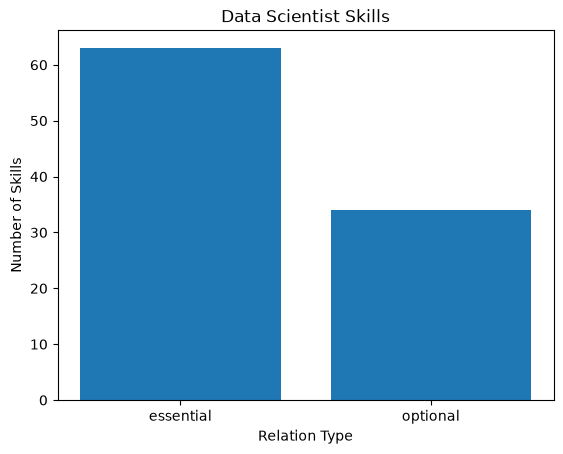

In [27]:
# Create a bar chart for essential and optional skills

import matplotlib.pyplot as plt

plt.bar(
    data_scientist_summary["relation_type"],
    data_scientist_summary["number_of_skills"]
)

plt.title("Data Scientist Skills")
plt.xlabel("Relation Type")
plt.ylabel("Number of Skills")

plt.show()

### Interpretation

About 64.9% of the data scientist concepts are essential, and 35.1% are
optional.

This suggests a future matching rule: an essential match should normally have
more weight than an optional match. However, the weight must be tested later.
It should not be chosen only because essential concepts are more common.

## 1.8 Part 1 Conclusion

**Part 1 question:** Is the ESCO data structured and complete enough for the
next analysis steps?

**Answer:** Yes, for this exploratory project.

The data has stable URI identifiers, clear occupation–concept relations, and
useful essential and optional labels. We removed duplicate IDs, filled the
small number of missing categories, and stored the clean tables in SQLite.

The data is now ready for occupation comparison. A small limit remains: five
concepts have an `unknown` category. We keep this visible in later results.

# Part 2 — Compare Data and AI Occupations

Part 1 prepared the data. Part 2 uses it to compare technical occupations.

The story now moves from one occupation to a group of nine occupations. We
study their concept counts, shared concepts, and similarity with the data
scientist profile.

## Part 2 contents

1. **2.1** Choose the occupations  
2. **2.2** Count essential and optional concepts  
3. **2.3** Compare the counts in a chart  
4. **2.4** Study the essential data scientist concepts  
5. **2.5** Compare essential concept types  
6. **2.6** Find concepts shared by several occupations  
7. **2.7** Measure similarity with data scientist  
8. **2.8** Inspect the closest pair

## Part 2 goal

The goal is to answer four questions:

1. How large is each ESCO occupation profile?
2. Which essential concepts are shared by several occupations?
3. Which selected occupation is most similar to data scientist?
4. Which concepts explain that similarity?

This comparison can later support career exploration and explainable matching.

## 2.1 Choose the Occupations

We first search ESCO for occupations with `data`, `artificial intelligence`,
or `machine learning` in the name.

This broad search gives us possible occupations. We then choose a smaller and
more focused group for a fair technical comparison.

In [28]:
# Find the available ESCO occupations related to data and AI

data_ai_occupations = pd.read_sql_query(
    """
    SELECT occupation_name, isco_group
    FROM occupations
    WHERE LOWER(occupation_name) LIKE '%data%'
       OR LOWER(occupation_name) LIKE '%artificial intelligence%'
       OR LOWER(occupation_name) LIKE '%machine learning%'
    ORDER BY occupation_name
    """,
    connection
)

display(data_ai_occupations)

,occupation_name,isco_group
0,artificial intelligence engineer,2511
1,aviation data communications manager,3513
2,big data archive librarian,3433
3,chief data officer,1330
4,data analyst,2511
5,data centre operator,3511
6,data engineer,2511
7,data entry clerk,4132
8,data entry supervisor,3341
9,data protection officer,2619


### Selection rules

We select nine occupations that work directly with data, AI, databases, or
data quality:

1. artificial intelligence engineer;
2. data analyst;
3. data engineer;
4. data quality specialist;
5. data scientist;
6. data warehouse designer;
7. database administrator;
8. database designer;
9. database developer.

Management, data-entry, legal, and library occupations are not selected. They
may contain the word `data`, but their main work is different from the
technical focus of this comparison.

In [29]:
# Get all skills connected to the nine selected data occupations

career_skills = pd.read_sql_query(
    """
    SELECT
        occupation_name,
        relation_type,
        skill_type,
        skill_name
    FROM relations
    WHERE occupation_name IN (
        'artificial intelligence engineer',
        'data analyst',
        'data engineer',
        'data quality specialist',
        'data scientist',
        'data warehouse designer',
        'database administrator',
        'database designer',
        'database developer'
    )
    ORDER BY occupation_name, relation_type, skill_name
    """,
    connection
)

print("Total number of skill relations:", len(career_skills))
display(career_skills.head(10))

Total number of skill relations: 717


,occupation_name,relation_type,skill_type,skill_name
0,artificial intelligence engineer,essential,knowledge,Python (computer programming)
1,artificial intelligence engineer,essential,knowledge,algorithms
2,artificial intelligence engineer,essential,skill/competence,analyse big data
3,artificial intelligence engineer,essential,skill/competence,analyse business requirements
4,artificial intelligence engineer,essential,skill/competence,apply ICT systems theory
5,artificial intelligence engineer,essential,knowledge,artificial neural networks
6,artificial intelligence engineer,essential,knowledge,business process modelling
7,artificial intelligence engineer,essential,knowledge,computer programming
8,artificial intelligence engineer,essential,knowledge,computer simulation
9,artificial intelligence engineer,essential,skill/competence,create data sets


### What did we learn?

The nine occupations have 717 essential and optional relations in total.

This table is the base for the rest of Part 2. Each row tells us which concept
is connected to which occupation and whether the link is essential or optional.

## 2.2 Count Essential and Optional Concepts

We count essential and optional concepts for every selected occupation.

A larger count means that ESCO gives the occupation a broader list. It does
not mean that the occupation is harder, better, or more valuable.

In [30]:
# Count the essential and optional skills for every occupation

skill_counts = (
    career_skills
    .groupby(["occupation_name", "relation_type"])
    .size()
    .reset_index(name="number_of_skills")
)

display(skill_counts)

,occupation_name,relation_type,number_of_skills
0,artificial intelligence engineer,essential,31
1,artificial intelligence engineer,optional,58
2,data analyst,essential,36
3,data analyst,optional,31
4,data engineer,essential,23
5,data engineer,optional,5
6,data quality specialist,essential,20
7,data quality specialist,optional,20
8,data scientist,essential,63
9,data scientist,optional,34


### What did we learn?

The profiles are different in size. Data scientist has the highest essential
count with 63 concepts. Database developer has the highest optional count with
96 concepts.

This first result shows why we should study both the size and the content of a
profile. A count alone does not tell us what the concepts are.

## 2.3 Compare the Counts in a Chart

The grouped bar chart makes the table easier to compare. Each occupation has
one bar for essential concepts and one bar for optional concepts.

The chart helps us find large differences, but the exact values still come
from the table above.

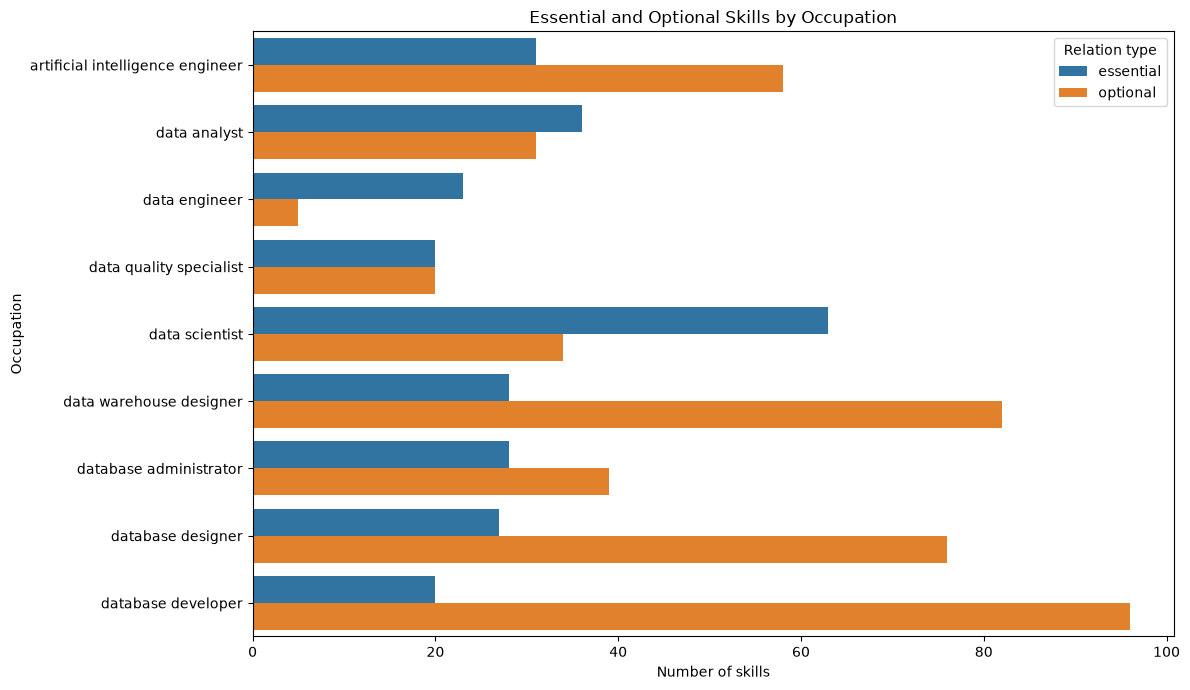

In [31]:
# Create a bar chart comparing essential and optional skills

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

sns.barplot(
    data=skill_counts,
    x="number_of_skills",
    y="occupation_name",
    hue="relation_type"
)

plt.title("Essential and Optional Skills by Occupation")
plt.xlabel("Number of skills")
plt.ylabel("Occupation")
plt.legend(title="Relation type")
plt.tight_layout()
plt.show()

### How to read the chart

Read the chart in three steps:

1. Find an occupation on the vertical axis.
2. Compare its essential and optional bars.
3. Compare the same bar type across occupations.

The chart describes ESCO v1.2.1. It does not measure demand, salary, seniority,
or difficulty.

## 2.4 Study the Essential Data Scientist Concepts

We now look inside the data scientist profile. A treemap shows all 63 essential
concepts.

Every small box represents one concept. The boxes are grouped into `knowledge`
and `skill/competence`. Every concept receives the same size because ESCO does
not give an importance score inside the essential group.

Move the mouse over a box to read the official description.

In [32]:
# Get the essential data scientist skills and their descriptions from SQL

data_scientist_essential = pd.read_sql_query(
    """
    SELECT DISTINCT
        r.skill_name,
        r.skill_type,
        s.skill_description
    FROM relations AS r
    LEFT JOIN skills AS s
        ON r.skill_uri = s.skill_uri
    WHERE r.occupation_name = 'data scientist'
      AND r.relation_type = 'essential'
    ORDER BY r.skill_type, r.skill_name
    """,
    connection
)

data_scientist_essential["occupation"] = "Data scientist"
data_scientist_essential["value"] = 1

print("Number of essential skills:", len(data_scientist_essential))
display(data_scientist_essential.head())

Number of essential skills: 63


,skill_name,skill_type,skill_description,occupation,value
0,data engineering,knowledge,The process of developing and constructing sys...,Data scientist,1
1,data ethics,knowledge,The subfield of ethics that assess whether dat...,Data scientist,1
2,data mining,knowledge,"The methods of artificial intelligence, machin...",Data scientist,1
3,data models,knowledge,The techniques and existing systems used for s...,Data scientist,1
4,data science,knowledge,The field of study that deals with big amount ...,Data scientist,1


In [33]:
# Create a treemap that shows the skill description when hovering

import plotly.express as px

fig = px.treemap(
    data_scientist_essential,
    path=["occupation", "skill_type", "skill_name"],
    values="value",
    color="skill_type",
    custom_data=["skill_description"],
    title="Essential Skills Required for a Data Scientist"
)

fig.update_traces(
    textinfo="label",
    hovertemplate=(
        "<b>%{label}</b>"
        "<br><br><b>Description:</b><br>"
        "%{customdata[0]}"
        "<extra></extra>"
    )
)

fig.update_layout(
    margin=dict(t=60, l=10, r=10, b=10)
)

fig.show()

### What did we learn?

The data scientist profile contains 63 essential concepts:

- 18 knowledge concepts;
- 45 skill/competence concepts.

The treemap shows that the profile mixes technical knowledge, research work,
data work, communication, and ethics. It should not be used as a checklist for
deciding whether someone is a “real” data scientist.

## 2.5 Compare Essential Concept Types

We now compare the essential `knowledge` and `skill/competence` counts across
all nine occupations.

This tells us how each profile is divided. The `unknown` category is shown
when ESCO does not provide a clear type.

In [34]:
# Count the essential concepts for each selected data and AI occupation

occupation_comparison = pd.read_sql_query(
    """
    SELECT
        occupation_name,
        skill_type,
        COUNT(DISTINCT skill_uri) AS number_of_concepts
    FROM relations
    WHERE relation_type = 'essential'
      AND occupation_name IN (
          'artificial intelligence engineer',
          'data analyst',
          'data engineer',
          'data scientist',
          'data quality specialist',
          'data warehouse designer',
          'database administrator',
          'database designer',
          'database developer'
      )
    GROUP BY occupation_name, skill_type
    ORDER BY occupation_name, skill_type
    """,
    connection
)

display(occupation_comparison)

,occupation_name,skill_type,number_of_concepts
0,artificial intelligence engineer,knowledge,19
1,artificial intelligence engineer,skill/competence,11
2,artificial intelligence engineer,unknown,1
3,data analyst,knowledge,19
4,data analyst,skill/competence,16
5,data analyst,unknown,1
6,data engineer,knowledge,8
7,data engineer,skill/competence,14
8,data engineer,unknown,1
9,data quality specialist,knowledge,5


In [35]:
# Create a grouped bar chart to compare the nine occupations

fig = px.bar(
    occupation_comparison,
    x="occupation_name",
    y="number_of_concepts",
    color="skill_type",
    barmode="group",
    title="Essential ESCO Concepts Across Data and AI Occupations",
    labels={
        "occupation_name": "Occupation",
        "number_of_concepts": "Number of essential concepts",
        "skill_type": "ESCO skill type"
    }
)

fig.update_layout(
    xaxis_tickangle=-45,
    margin=dict(t=60, l=20, r=20, b=160)
)

fig.show()

### What did we learn?

Data scientist has the broadest essential profile in this selected group.
Artificial intelligence engineer and data analyst have more knowledge
concepts than skill/competence concepts. Most other occupations show the
opposite pattern.

Three occupations contain one `unknown` concept. We keep it in this chart to
show the data limit clearly.

## 2.6 Find Concepts Shared by Several Occupations

Counts show profile size. Shared concepts show what connects the occupations.

We count how many selected occupations contain each essential concept. A
concept must appear in at least two occupations to enter this result.

In [36]:
# Find essential concepts shared by at least two selected occupations

shared_concepts = pd.read_sql_query(
    """
    SELECT
        skill_uri,
        skill_name,
        skill_type,
        COUNT(DISTINCT occupation_name) AS number_of_occupations
    FROM relations
    WHERE relation_type = 'essential'
      AND occupation_name IN (
          'artificial intelligence engineer',
          'data analyst',
          'data engineer',
          'data scientist',
          'data quality specialist',
          'data warehouse designer',
          'database administrator',
          'database designer',
          'database developer'
      )
    GROUP BY skill_uri, skill_name, skill_type
    HAVING COUNT(DISTINCT occupation_name) >= 2
    ORDER BY number_of_occupations DESC, skill_name
    """,
    connection
)

display(shared_concepts.head(15))

,skill_uri,skill_name,skill_type,number_of_occupations
0,http://data.europa.eu/esco/skill/99207709-d076...,resource description framework query language,knowledge,8
1,http://data.europa.eu/esco/skill/9cf681c7-89ec...,query languages,knowledge,7
2,http://data.europa.eu/esco/skill/03ff0d53-573a...,information structure,knowledge,6
3,http://data.europa.eu/esco/skill/4463a721-69f3...,use databases,skill/competence,6
4,http://data.europa.eu/esco/skill/fecf8a0d-62c4...,data models,knowledge,5
5,http://data.europa.eu/esco/skill/ab1e97ed-2319...,database management systems,knowledge,5
6,http://data.europa.eu/esco/skill/6c08403c-a5bb...,design database scheme,skill/competence,5
7,http://data.europa.eu/esco/skill/1b70a55d-b8a4...,use data processing techniques,skill/competence,5
8,http://data.europa.eu/esco/skill/906323f4-00c4...,create data sets,skill/competence,4
9,http://data.europa.eu/esco/skill/9ef0f3a0-9ce2...,database development tools,knowledge,4


In [37]:
# Select the 15 concepts shared by the largest number of occupations

top_shared_concepts = shared_concepts.head(15).sort_values(
    "number_of_occupations", ascending=True
)

display(top_shared_concepts)

,skill_uri,skill_name,skill_type,number_of_occupations
14,http://data.europa.eu/esco/skill/98301d4a-2cc3...,business process modelling,knowledge,3
12,http://data.europa.eu/esco/skill/b04f377b-ee80...,analyse business requirements,skill/competence,3
13,http://data.europa.eu/esco/skill/cbe2c304-1e7d...,apply ICT systems theory,skill/competence,3
8,http://data.europa.eu/esco/skill/906323f4-00c4...,create data sets,skill/competence,4
10,http://data.europa.eu/esco/skill/2daec0e6-f0c1...,establish data processes,skill/competence,4
9,http://data.europa.eu/esco/skill/9ef0f3a0-9ce2...,database development tools,knowledge,4
11,http://data.europa.eu/esco/skill/29fb0fb5-dfc4...,manage database,skill/competence,4
7,http://data.europa.eu/esco/skill/1b70a55d-b8a4...,use data processing techniques,skill/competence,5
4,http://data.europa.eu/esco/skill/fecf8a0d-62c4...,data models,knowledge,5
5,http://data.europa.eu/esco/skill/ab1e97ed-2319...,database management systems,knowledge,5


In [38]:
# Visualise the most widely shared essential concepts

fig = px.bar(
    top_shared_concepts,
    x="number_of_occupations",
    y="skill_name",
    color="skill_type",
    orientation="h",
    text="number_of_occupations",
    title="Most Widely Shared Essential Concepts",
    labels={
        "number_of_occupations": "Number of occupations",
        "skill_name": "Essential concept",
        "skill_type": "ESCO skill type"
    }
)

fig.update_layout(
    yaxis_title="",
    margin=dict(t=60, l=200, r=20, b=40)
)

fig.show()

### What did we learn?

The most shared essential concept is **resource description framework query
language**, which appears in eight of the nine profiles. **Query languages**
appears in seven profiles, while **information structure** and **use
databases** appear in six.

This suggests that query and database concepts connect many of the selected
data occupations. However, a widely shared concept is not automatically the
most important concept.

## 2.7 Measure Similarity with Data Scientist

We want to know which occupation has the most similar essential-concept list
to data scientist.

We use **Jaccard similarity**. It compares the shared concepts with all unique
concepts found in the two profiles. URI values are used because they are unique.

### A simple Jaccard example

Imagine two small profiles:

- Profile A: Python, SQL, statistics, machine learning;
- Profile B: SQL, statistics, data visualisation.

They share two concepts: SQL and statistics. Together, they have five unique
concepts.

`Jaccard similarity = 2 shared / 5 unique × 100 = 40%`

The percentage measures overlap between the lists. It does not mean that one
person can do 40% of another job.

In [39]:
# Load the essential concepts for the nine selected occupations

selected_relations = pd.read_sql_query(
    """
    SELECT DISTINCT
        occupation_name,
        skill_uri,
        skill_name
    FROM relations
    WHERE relation_type = 'essential'
      AND occupation_name IN (
          'artificial intelligence engineer',
          'data analyst',
          'data engineer',
          'data scientist',
          'data quality specialist',
          'data warehouse designer',
          'database administrator',
          'database designer',
          'database developer'
      )
    """,
    connection
)

display(selected_relations.head())

,occupation_name,skill_uri,skill_name
0,data warehouse designer,http://data.europa.eu/esco/skill/03ff0d53-573a...,information structure
1,data warehouse designer,http://data.europa.eu/esco/skill/3ec2e4d6-7000...,data warehouse
2,data warehouse designer,http://data.europa.eu/esco/skill/43ae58b9-5e56...,database
3,data warehouse designer,http://data.europa.eu/esco/skill/69bbd53f-fbb0...,web programming
4,data warehouse designer,http://data.europa.eu/esco/skill/7814e88f-c133...,ICT security legislation


In [40]:
# Calculate the similarity between data scientist and every other occupation

data_scientist_concepts = set(
    selected_relations[
        selected_relations["occupation_name"] == "data scientist"
    ]["skill_uri"]
)

similarity_results = []

for occupation in selected_relations["occupation_name"].unique():

    if occupation == "data scientist":
        continue

    occupation_concepts = set(
        selected_relations[
            selected_relations["occupation_name"] == occupation
        ]["skill_uri"]
    )

    shared_concepts = data_scientist_concepts.intersection(
        occupation_concepts
    )

    all_concepts = data_scientist_concepts.union(
        occupation_concepts
    )

    similarity_percentage = (
        len(shared_concepts) / len(all_concepts)
    ) * 100

    similarity_results.append({
        "occupation_name": occupation,
        "shared_concepts": len(shared_concepts),
        "similarity_percentage": round(similarity_percentage, 1)
    })

occupation_similarity = pd.DataFrame(similarity_results)

occupation_similarity = occupation_similarity.sort_values(
    "similarity_percentage",
    ascending=False
).reset_index(drop=True)

display(occupation_similarity)

,occupation_name,shared_concepts,similarity_percentage
0,data analyst,22,28.6
1,data quality specialist,11,15.3
2,artificial intelligence engineer,9,10.6
3,data engineer,6,7.5
4,database administrator,5,5.8
5,database developer,4,5.1
6,data warehouse designer,4,4.6
7,database designer,3,3.4


In [41]:
# Visualise which occupations are most similar to data scientist

fig = px.bar(
    occupation_similarity.sort_values("similarity_percentage"),
    x="similarity_percentage",
    y="occupation_name",
    orientation="h",
    text="similarity_percentage",
    title="Similarity with the ESCO Data Scientist Profile",
    labels={
        "similarity_percentage": "Similarity (%)",
        "occupation_name": "Occupation"
    }
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.update_layout(
    yaxis_title="",
    margin=dict(t=60, l=200, r=60, b=40)
)

fig.show()

### Interpretation

Data analyst is the closest selected occupation to data scientist. They share
22 essential concepts and have a Jaccard similarity of 28.6%.

The calculation is:

`22 shared concepts / 77 unique concepts × 100 = 28.6%`

This does not mean that a data analyst is “28.6% of a data scientist.” It only
describes overlap in the ESCO essential-concept lists.

## 2.8 Inspect Data Scientist and Data Analyst

The similarity score tells us which pair is closest. It does not tell us which
concepts create the score.

We therefore join the data scientist and data analyst relations by
`skill_uri`. The result lists only concepts that are essential for both
occupations.

In [42]:
# Find the essential concepts shared by data scientist and data analyst

shared_data_scientist_analyst = pd.read_sql_query(
    """
    SELECT DISTINCT
        data_scientist.skill_uri,
        data_scientist.skill_name,
        data_scientist.skill_type
    FROM relations AS data_scientist

    INNER JOIN relations AS data_analyst
        ON data_scientist.skill_uri = data_analyst.skill_uri

    WHERE data_scientist.occupation_name = 'data scientist'
      AND data_analyst.occupation_name = 'data analyst'
      AND data_scientist.relation_type = 'essential'
      AND data_analyst.relation_type = 'essential'

    ORDER BY data_scientist.skill_type, data_scientist.skill_name
    """,
    connection
)

print(
    "Number of shared essential concepts:",
    len(shared_data_scientist_analyst)
)

display(shared_data_scientist_analyst)

Number of shared essential concepts: 22


,skill_uri,skill_name,skill_type
0,http://data.europa.eu/esco/skill/48db96bf-3314...,data engineering,knowledge
1,http://data.europa.eu/esco/skill/e9575f7f-053a...,data ethics,knowledge
2,http://data.europa.eu/esco/skill/25f0ea33-b4a2...,data mining,knowledge
3,http://data.europa.eu/esco/skill/fecf8a0d-62c4...,data models,knowledge
4,http://data.europa.eu/esco/skill/edebd83d-35f6...,data science,knowledge
5,http://data.europa.eu/esco/skill/65e58886-bd1e...,data visualisation software,knowledge
6,http://data.europa.eu/esco/skill/93aaf65c-5aad...,information categorisation,knowledge
7,http://data.europa.eu/esco/skill/696e3b5b-8b61...,information extraction,knowledge
8,http://data.europa.eu/esco/skill/9cf681c7-89ec...,query languages,knowledge
9,http://data.europa.eu/esco/skill/99207709-d076...,resource description framework query language,knowledge


In [43]:
# Count the shared concepts by ESCO skill type

shared_type_summary = (
    shared_data_scientist_analyst["skill_type"]
    .value_counts()
    .rename_axis("skill_type")
    .reset_index(name="number_of_shared_concepts")
)

display(shared_type_summary)

,skill_type,number_of_shared_concepts
0,knowledge,12
1,skill/competence,10


### What did we learn?

The two profiles share 22 essential concepts:

- 12 knowledge concepts;
- 10 skill/competence concepts.

Examples include data engineering, data ethics, statistics, data cleansing,
and using databases. These concepts explain the similarity instead of leaving
us with only one percentage.

## Part 2 Conclusion

Part 2 compared nine occupations with their ESCO concepts.

Data scientist has the largest essential profile with 63 concepts. Data
analyst is the closest selected profile, with 22 shared essential concepts and
28.6% Jaccard similarity. Query and database concepts also connect many of the
selected occupations.

These results help explain relationships between occupations. They do not
measure job quality, difficulty, salary, or labour-market demand. The results
only describe the selected profiles in ESCO v1.2.1.

# Part 3 — Test a Pattern

Part 2 showed a possible pattern: most selected occupations seem to contain
more essential skill/competence concepts than knowledge concepts.

In Part 3, we describe this pattern and use a small statistical test. The test
helps us avoid making a strong claim from counts alone.

## Part 3 contents

1. **3.1** Define the goal, question, and hypotheses  
2. **3.2** Prepare one comparison row per occupation  
3. **3.3** Explore the differences  
4. **3.4** Run an exact sign test  
5. **3.5** Interpret the result

## 3.1 Goal, Question, and Hypotheses

The goal is to compare the number of essential knowledge concepts with the
number of essential skill/competence concepts across the nine selected
occupations.

### Research question

> Do the selected data and AI occupations generally contain more essential
> skill/competence concepts than knowledge concepts?

### Hypotheses

**Null hypothesis (H₀):** An occupation is equally likely to have more
knowledge concepts or more skill/competence concepts.

**Alternative hypothesis (H₁):** An occupation is more likely to have more
skill/competence concepts.

### Important limit

The nine occupations were selected for this project. They are not a random
sample of all occupations. ESCO is also a classification, not a survey.

The test is therefore exploratory. It can describe this selected group, but it
cannot prove a rule for the full labour market.

## 3.2 Prepare the Comparison Table

We need one row for each occupation. The row contains:

- the knowledge count;
- the skill/competence count;
- the difference between them.

The calculation is:

`difference = skill/competence count - knowledge count`

The `unknown` category is not used because it is not one of the two categories
in the research question.

In [44]:
# Create one row per occupation with separate knowledge and competence counts

skill_type_comparison = (
    occupation_comparison[
        occupation_comparison["skill_type"].isin([
            "knowledge",
            "skill/competence"
        ])
    ]
    .pivot(
        index="occupation_name",
        columns="skill_type",
        values="number_of_concepts"
    )
    .fillna(0)
    .reset_index()
)

skill_type_comparison.columns.name = None

skill_type_comparison = skill_type_comparison.rename(
    columns={"skill/competence": "skill_competence"}
)

skill_type_comparison["difference"] = (
    skill_type_comparison["skill_competence"]
    - skill_type_comparison["knowledge"]
)

display(skill_type_comparison)

,occupation_name,knowledge,skill_competence,difference
0,artificial intelligence engineer,19,11,-8
1,data analyst,19,16,-3
2,data engineer,8,14,6
3,data quality specialist,5,15,10
4,data scientist,18,45,27
5,data warehouse designer,11,17,6
6,database administrator,11,17,6
7,database designer,11,16,5
8,database developer,7,13,6


### How to read the difference

- A positive value means more skill/competence concepts.
- A negative value means more knowledge concepts.
- Zero means the two counts are equal.

For example, data scientist has 45 skill/competence concepts and 18 knowledge
concepts. Its difference is `45 - 18 = 27`.

## 3.3 Explore the Differences

Before the statistical test, we describe the data.

We count positive, negative, and equal differences. We also calculate the
median difference. The median is useful because the data scientist difference
of 27 is much larger than most other differences.

In [45]:
# Calculate a simple summary of the differences

more_competence = (
    skill_type_comparison["difference"] > 0
).sum()

more_knowledge = (
    skill_type_comparison["difference"] < 0
).sum()

equal_counts = (
    skill_type_comparison["difference"] == 0
).sum()

median_difference = skill_type_comparison[
    "difference"
].median()

print("Occupations with more skill/competence:", more_competence)
print("Occupations with more knowledge:", more_knowledge)
print("Occupations with equal counts:", equal_counts)
print("Median difference:", median_difference)

Occupations with more skill/competence: 7
Occupations with more knowledge: 2
Occupations with equal counts: 0
Median difference: 6.0


In [46]:
# Create a label showing which concept type is more common

skill_type_comparison["dominant_type"] = (
    skill_type_comparison["difference"].apply(
        lambda value: (
            "More skill/competence"
            if value > 0
            else "More knowledge"
        )
    )
)

In [47]:
# Visualise the difference for every selected occupation

difference_chart_data = skill_type_comparison.sort_values(
    "difference"
)

fig = px.bar(
    difference_chart_data,
    x="occupation_name",
    y="difference",
    color="dominant_type",
    text="difference",
    title="Difference Between Skill/Competence and Knowledge Concepts",
    labels={
        "occupation_name": "Occupation",
        "difference": "Difference in number of concepts",
        "dominant_type": "Result"
    },
    color_discrete_map={
        "More skill/competence": "#2E8B57",
        "More knowledge": "#D9534F"
    }
)

fig.add_hline(y=0, line_color="black")

fig.update_layout(
    xaxis_tickangle=-45,
    margin=dict(t=60, l=30, r=30, b=160)
)

fig.show()

### What did we learn?

Seven occupations have more skill/competence concepts. Two occupations have
more knowledge concepts: artificial intelligence engineer and data analyst.
No occupation has equal counts.

The median difference is 6. This describes a pattern, but it does not yet tell
us whether the evidence is strong enough for the alternative hypothesis.

## 3.4 Run the Exact Sign Test

We use a one-sided exact sign test. The test asks whether positive differences
happen more often than expected when positive and negative differences are
equally likely.

It uses the direction of each difference. It does not use the size of the
difference.

### Why this test?

The sign test is suitable here because:

- the two counts belong to the same occupation;
- the sample is small;
- we do not need to assume a normal distribution;
- the hypothesis is about the direction of the differences.

The test is simple and cautious, but it also loses information because a
difference of 1 and a difference of 27 both count as one positive result.

### Decision rule

We use a significance level of 5% (`α = 0.05`).

- If `p-value < 0.05`, reject H₀.
- If `p-value ≥ 0.05`, do not reject H₀.

“Do not reject” does not prove that H₀ is true. It means that this dataset does
not give strong enough evidence against H₀.

In [48]:
# Import the function used for the exact sign test

from scipy.stats import binomtest

# Count the positive and non-zero differences

positive_differences = (
    skill_type_comparison["difference"] > 0
).sum()

non_zero_differences = (
    skill_type_comparison["difference"] != 0
).sum()

print("Positive differences:", positive_differences)
print("Non-zero differences:", non_zero_differences)

Positive differences: 7
Non-zero differences: 9


In [49]:
# Perform a one-sided exact sign test

sign_test = binomtest(
    k=positive_differences,
    n=non_zero_differences,
    p=0.5,
    alternative="greater"
)

p_value = sign_test.pvalue

print("Proportion with a positive difference:", round(sign_test.statistic, 3))
print("P-value:", round(p_value, 4))

Proportion with a positive difference: 0.778
P-value: 0.0898


In [50]:
# Compare the p-value with the 5% significance level

alpha = 0.05

if p_value < alpha:
    print("Reject H₀: the result is statistically significant.")
else:
    print("Do not reject H₀: the result is not statistically significant.")

Do not reject H₀: the result is not statistically significant.


### Test result

Seven of the nine non-zero differences are positive. The exact sign test gives
a p-value of **0.0898**.

Because `0.0898 > 0.05`, we do not reject the null hypothesis. The result is
not statistically significant at the 5% level.

## 3.5 Part 3 Conclusion

Seven of the nine occupations have more skill/competence concepts than
knowledge concepts.

However, the p-value of 0.0898 is higher than 0.05. The result is not
statistically significant.

The selected data shows a pattern, but there is not enough evidence to make a
general conclusion. The small, non-random group of occupations is an important
limit.

# Part 4 — Modelling and Power BI export

## Occupation recommendation modelling and Power BI export

In Parts 1–3, we cleaned the ESCO data, explored nine data and AI
occupations, studied their essential concepts, measured similarity, and
tested research questions.

Part 4 turns this work into a small recommendation prototype. We train two
machine-learning models, compare their results, explain one recommendation,
and export clean tables for Power BI.


## Contents

- 4.1 Goal, question, and honest boundary
- 4.2 Load and prepare the data
- 4.3 Create partial skill profiles
- 4.4 Split the profiles
- 4.5 Build pipelines and hyperparameter grids
- 4.6 Tune and compare the models
- 4.7 Evaluate the best model
- 4.8 Test whether the model difference is meaningful
- 4.9 Explain one recommendation
- 4.10 Export a Power BI data model
- 4.11 Final project conclusion

### Research question



>**Can a model connect a partial list of skills to the most similar ESCO
>occupation among our nine selected occupations?**

The final result is a prototype. It is useful for learning and exploration,
but it must not make a hiring decision.

## 4.1 Goal, research question, and honest boundary

### Goal

Build and compare two occupation-recommendation models:

1. Logistic Regression
2. K-nearest neighbours (KNN)

We use a `Pipeline` so the vectorizer and model always work together. We
use `GridSearchCV` to test several hyperparameter values and select the best
setting with cross-validation.

### Important boundary

ESCO does not contain labelled CVs or real candidate outcomes. Therefore,
we create **simulated partial profiles** from the ESCO occupation concepts.
The test measures whether a model can recover ESCO patterns. It does not
measure real job performance, hiring quality, or a person's ability.

Official references:

- [ESCO download page](https://esco.ec.europa.eu/en/use-esco/download)
- [scikit-learn Pipeline](https://scikit-learn.org/stable/modules/compose.html#pipeline)
- [scikit-learn grid search](https://scikit-learn.org/stable/modules/grid_search.html)
- [Microsoft Power BI star schema guidance](https://learn.microsoft.com/en-us/power-bi/guidance/star-schema)

## 4.2 Load and prepare the data

We need the full ESCO relations and skills files. The function below looks
in common folders. It also gives a clear error if a file is missing.

We then keep only the nine occupations selected in Part 2. A validation
check stops the notebook if one of these occupations is missing. This
protects the project from using an incomplete CSV by mistake.

In [51]:
# Import the libraries used in Part 4
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binomtest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    top_k_accuracy_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [52]:
# Find a required CSV in a few common project folders
def find_data_file(filename):
    folders = [
        Path("."),
        Path("data"),
        Path("library_source"),
        Path("upload"),
        Path("../data"),
    ]

    for folder in folders:
        path = folder / filename
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not find {filename}. Put it in the notebook folder or data folder."
    )


RELATIONS_FILE = find_data_file("occupationSkillRelations_en.csv")
SKILLS_FILE = find_data_file("skills_en.csv")

print("Relations file:", RELATIONS_FILE)
print("Skills file:", SKILLS_FILE)

Relations file: occupationSkillRelations_en.csv
Skills file: skills_en.csv


In [53]:
# Load the complete source files and use clear column names
raw_relations = pd.read_csv(RELATIONS_FILE)
raw_skills = pd.read_csv(SKILLS_FILE)

relations = raw_relations.rename(columns={
    "occupationUri": "occupation_uri",
    "occupationLabel": "occupation_name",
    "relationType": "relation_type",
    "skillType": "skill_type",
    "skillUri": "skill_uri",
    "skillLabel": "skill_name",
})

skills = raw_skills.rename(columns={
    "conceptUri": "skill_uri",
    "skillType": "skill_type_lookup",
    "preferredLabel": "skill_name_lookup",
    "description": "skill_description",
})[[
    "skill_uri",
    "skill_type_lookup",
    "skill_name_lookup",
    "skill_description",
]]

source_summary = pd.DataFrame({
    "dataset": ["Occupation-skill relations", "Skills"],
    "rows": [len(raw_relations), len(raw_skills)],
    "columns": [raw_relations.shape[1], raw_skills.shape[1]],
})

display(source_summary)

,dataset,rows,columns
0,Occupation-skill relations,126051,6
1,Skills,13960,13


In [54]:
# Keep the nine selected occupations and check that all are available
SELECTED_OCCUPATIONS = [
    "artificial intelligence engineer",
    "data analyst",
    "data engineer",
    "data quality specialist",
    "data scientist",
    "data warehouse designer",
    "database administrator",
    "database designer",
    "database developer",
]

for column in ["occupation_name", "relation_type", "skill_name"]:
    relations[column] = relations[column].astype(str).str.strip().str.lower()

selected_relations = relations[
    relations["occupation_name"].isin(SELECTED_OCCUPATIONS)
].copy()

selected_relations = selected_relations.drop_duplicates(
    subset=["occupation_name", "relation_type", "skill_uri"]
)

selected_relations = selected_relations.merge(skills, on="skill_uri", how="left")
selected_relations["skill_type"] = selected_relations["skill_type"].fillna(
    selected_relations["skill_type_lookup"]
).fillna("unknown")
selected_relations["skill_description"] = selected_relations[
    "skill_description"
].fillna("No description is available in this ESCO file.")

missing_occupations = sorted(
    set(SELECTED_OCCUPATIONS) - set(selected_relations["occupation_name"].unique())
)

if missing_occupations:
    raise ValueError(f"The relation file is incomplete: {missing_occupations}")

print("All nine occupations are available.")

All nine occupations are available.


In [55]:
# Count essential and optional concepts for every selected occupation
occupation_summary = (
    selected_relations
    .groupby(["occupation_name", "relation_type"])["skill_uri"]
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)

occupation_summary["total_concepts"] = occupation_summary.select_dtypes(
    include="number"
).sum(axis=1)

display(occupation_summary)

relation_type,occupation_name,essential,optional,total_concepts
0,artificial intelligence engineer,31,58,89
1,data analyst,36,31,67
2,data engineer,23,5,28
3,data quality specialist,20,20,40
4,data scientist,63,34,97
5,data warehouse designer,28,82,110
6,database administrator,28,39,67
7,database designer,27,76,103
8,database developer,20,96,116


### What did we learn?

The complete source contains **126,051 relations** and
**13,960 skill records**. All nine selected occupations are
present.

The occupations have different numbers of concepts. This difference is one
reason why we should evaluate every occupation separately, not only report
one total accuracy number.

## 4.3 Create partial skill profiles

We do not have real labelled CVs. We therefore create 160 learning profiles
for each occupation.

Each profile contains:

- 25% to 65% of that occupation's essential concepts;
- a small number of optional concepts;
- zero to four unrelated concepts as noise.

This makes the profiles incomplete and imperfect. However, they still come
from ESCO, so the experiment only tests ESCO-pattern recovery.

In [56]:
# Give every ESCO concept a short token for the text vectorizer
all_skill_uris = sorted(selected_relations["skill_uri"].unique())
uri_to_token = {
    uri: f"skill_{number:04d}"
    for number, uri in enumerate(all_skill_uris, start=1)
}

selected_relations["skill_token"] = selected_relations["skill_uri"].map(
    uri_to_token
)

print("Unique concepts used by the nine occupations:", len(uri_to_token))

Unique concepts used by the nine occupations: 293


In [57]:
# Create incomplete profiles with essential, optional, and noise concepts
def create_partial_profiles(
    data,
    occupations,
    profiles_per_occupation=160,
    random_state=42,
):
    rng = np.random.default_rng(random_state)
    profile_rows = []
    all_tokens = set(data["skill_token"])

    for occupation_number, occupation in enumerate(occupations, start=1):
        occupation_data = data[data["occupation_name"] == occupation]
        occupation_tokens = set(occupation_data["skill_token"])
        unrelated_tokens = np.array(sorted(all_tokens - occupation_tokens))

        essential_tokens = occupation_data.loc[
            occupation_data["relation_type"] == "essential", "skill_token"
        ].unique()
        optional_tokens = occupation_data.loc[
            occupation_data["relation_type"] == "optional", "skill_token"
        ].unique()

        for profile_number in range(profiles_per_occupation):
            essential_fraction = rng.uniform(0.25, 0.65)
            optional_fraction = rng.uniform(0.00, 0.08)

            essential_count = max(
                3,
                int(round(len(essential_tokens) * essential_fraction)),
            )
            optional_count = int(round(len(optional_tokens) * optional_fraction))

            chosen_essential = rng.choice(
                essential_tokens,
                size=min(essential_count, len(essential_tokens)),
                replace=False,
            )

            if optional_count > 0 and len(optional_tokens) > 0:
                chosen_optional = rng.choice(
                    optional_tokens,
                    size=min(optional_count, len(optional_tokens)),
                    replace=False,
                )
            else:
                chosen_optional = np.array([], dtype=object)

            noise_count = int(rng.integers(0, 5))
            if noise_count > 0:
                chosen_noise = rng.choice(
                    unrelated_tokens,
                    size=min(noise_count, len(unrelated_tokens)),
                    replace=False,
                )
            else:
                chosen_noise = np.array([], dtype=object)

            chosen_tokens = sorted(
                set(chosen_essential)
                | set(chosen_optional)
                | set(chosen_noise)
            )

            profile_rows.append({
                "profile_id": f"P{occupation_number:02d}_{profile_number:03d}",
                "occupation_name": occupation,
                "profile_text": " ".join(chosen_tokens),
                "number_of_concepts": len(chosen_tokens),
            })

    return pd.DataFrame(profile_rows)

In [58]:
# Create the profiles and review their sizes
profiles = create_partial_profiles(
    selected_relations,
    SELECTED_OCCUPATIONS,
    profiles_per_occupation=160,
    random_state=RANDOM_STATE,
)

profile_summary = (
    profiles
    .groupby("occupation_name")["number_of_concepts"]
    .agg(["count", "min", "mean", "max"])
    .round(1)
    .reset_index()
)

print("Total simulated profiles:", len(profiles))
display(profile_summary)

Total simulated profiles: 1440


,occupation_name,count,min,mean,max
0,artificial intelligence engineer,160,9,18.6,27
1,data analyst,160,10,18.7,28
2,data engineer,160,6,12.8,19
3,data quality specialist,160,6,11.6,18
4,data scientist,160,17,31.6,47
5,data warehouse designer,160,9,18.2,27
6,database administrator,160,8,16.5,25
7,database designer,160,8,17.0,25
8,database developer,160,6,14.9,22


### Why do we use tokens?

A profile is stored as text such as `skill_0004 skill_0021 skill_0170`.
Every token represents one ESCO concept URI.

This lets `TfidfVectorizer` create a numeric feature for every concept. The
models learn which combinations of concepts are connected to each
occupation. We keep the original names and descriptions in separate tables
so the result remains understandable.

## 4.4 Split the profiles

We use 75% of the profiles for training and keep 25% for the final test.
`stratify` keeps the same number of profiles for every occupation. The test
set is not used during hyperparameter tuning.

In [59]:
# Split the profiles into training and final test sets
train_index, test_index = train_test_split(
    profiles.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=profiles["occupation_name"],
)

X_train = profiles.loc[train_index, "profile_text"]
y_train = profiles.loc[train_index, "occupation_name"]
X_test = profiles.loc[test_index, "profile_text"]
y_test = profiles.loc[test_index, "occupation_name"]

split_summary = pd.DataFrame({
    "set": ["Training", "Test", "Total"],
    "profiles": [len(X_train), len(X_test), len(profiles)],
    "share": [
        f"{len(X_train) / len(profiles):.0%}",
        f"{len(X_test) / len(profiles):.0%}",
        "100%",
    ],
})

display(split_summary)

,set,profiles,share
0,Training,1080,75%
1,Test,360,25%
2,Total,1440,100%


## 4.5 Build pipelines and hyperparameter grids

A pipeline joins data preparation and a model in one object. This reduces
the risk of using different preparation steps during training and testing.

The names with two underscores, such as `model__C`, mean: use the parameter
`C` inside the pipeline step named `model`.

Grid search will test 12 Logistic Regression settings and 16 KNN settings.
Four-fold cross-validation will compare them using macro F1. Macro F1 gives
every occupation the same importance.

In [60]:
# Build the Logistic Regression pipeline and its parameter grid
logistic_pipeline = Pipeline(steps=[
    (
        "tfidf",
        TfidfVectorizer(
            token_pattern=r"(?u)\bskill_\d+\b",
            lowercase=False,
        ),
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE,
        ),
    ),
])

logistic_grid = {
    "tfidf__use_idf": [True, False],
    "tfidf__norm": ["l1", "l2"],
    "model__C": [0.5, 1.0, 5.0],
}

In [61]:
# Build the K-nearest neighbours pipeline and its parameter grid
knn_pipeline = Pipeline(steps=[
    (
        "tfidf",
        TfidfVectorizer(
            token_pattern=r"(?u)\bskill_\d+\b",
            lowercase=False,
        ),
    ),
    (
        "model",
        KNeighborsClassifier(
            metric="cosine",
            algorithm="brute",
        ),
    ),
])

knn_grid = {
    "tfidf__use_idf": [True, False],
    "model__n_neighbors": [3, 5, 9, 15],
    "model__weights": ["uniform", "distance"],
}

In [62]:
# Put both pipelines and their grids in one dictionary
models = {
    "Logistic regression": (logistic_pipeline, logistic_grid),
    "K-nearest neighbours": (knn_pipeline, knn_grid),
}

search_space_summary = pd.DataFrame({
    "model": ["Logistic regression", "K-nearest neighbours"],
    "parameters_tested": [12, 16],
    "main_hyperparameters": [
        "C, TF-IDF norm, use IDF",
        "number of neighbours, weights, use IDF",
    ],
})

display(search_space_summary)

,model,parameters_tested,main_hyperparameters
0,Logistic regression,12,"C, TF-IDF norm, use IDF"
1,K-nearest neighbours,16,"number of neighbours, weights, use IDF"


## 4.6 Tune and compare the models

Grid search trains every parameter combination during cross-validation.
After it selects the best setting, we evaluate that final pipeline on the
separate test set.

We report four values:

- **CV macro F1:** average validation result during tuning;
- **test accuracy:** share of correct first recommendations;
- **test macro F1:** balanced score across all nine occupations;
- **test top-3 accuracy:** share where the correct occupation appears in the
  first three recommendations.

In [63]:
# Tune both pipelines and save their test results
cross_validation = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=RANDOM_STATE,
)

searches = {}
metric_rows = []
classification_rows = []
confusion_rows = []
prediction_rows = []

for model_name, (pipeline, parameter_grid) in models.items():
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=parameter_grid,
        scoring="f1_macro",
        cv=cross_validation,
        n_jobs=1,
        refit=True,
    )
    search.fit(X_train, y_train)
    searches[model_name] = search

    predictions = search.predict(X_test)
    probabilities = search.predict_proba(X_test)
    classes = search.best_estimator_.classes_

    metric_rows.append({
        "model": model_name,
        "cv_macro_f1": search.best_score_,
        "test_accuracy": accuracy_score(y_test, predictions),
        "test_macro_f1": f1_score(y_test, predictions, average="macro"),
        "test_top_3_accuracy": top_k_accuracy_score(
            y_test, probabilities, k=3, labels=classes
        ),
        "best_parameters": json.dumps(search.best_params_, sort_keys=True),
    })

    report = classification_report(
        y_test,
        predictions,
        labels=SELECTED_OCCUPATIONS,
        output_dict=True,
        zero_division=0,
    )

    for occupation in SELECTED_OCCUPATIONS:
        classification_rows.append({
            "model": model_name,
            "occupation_name": occupation,
            "precision": report[occupation]["precision"],
            "recall": report[occupation]["recall"],
            "f1_score": report[occupation]["f1-score"],
            "support": int(report[occupation]["support"]),
        })

    matrix = confusion_matrix(
        y_test, predictions, labels=SELECTED_OCCUPATIONS
    )
    for actual_number, actual in enumerate(SELECTED_OCCUPATIONS):
        for predicted_number, predicted in enumerate(SELECTED_OCCUPATIONS):
            confusion_rows.append({
                "model": model_name,
                "actual_occupation": actual,
                "predicted_occupation": predicted,
                "number_of_profiles": int(
                    matrix[actual_number, predicted_number]
                ),
            })

    for row_number, profile_index in enumerate(test_index):
        prediction_rows.append({
            "model": model_name,
            "profile_id": profiles.loc[profile_index, "profile_id"],
            "actual_occupation": y_test.loc[profile_index],
            "predicted_occupation": predictions[row_number],
            "correct_prediction": (
                y_test.loc[profile_index] == predictions[row_number]
            ),
        })

model_metrics = pd.DataFrame(metric_rows).sort_values(
    "test_macro_f1", ascending=False
).reset_index(drop=True)
classification_metrics = pd.DataFrame(classification_rows)
confusion_data = pd.DataFrame(confusion_rows)
test_predictions = pd.DataFrame(prediction_rows)

display(model_metrics)

,model,cv_macro_f1,test_accuracy,test_macro_f1,test_top_3_accuracy,best_parameters
0,Logistic regression,0.971217,0.972222,0.972205,1.0,"{""model__C"": 5.0, ""tfidf__norm"": ""l1"", ""tfidf_..."
1,K-nearest neighbours,0.964643,0.972222,0.972205,1.0,"{""model__n_neighbors"": 15, ""model__weights"": ""..."


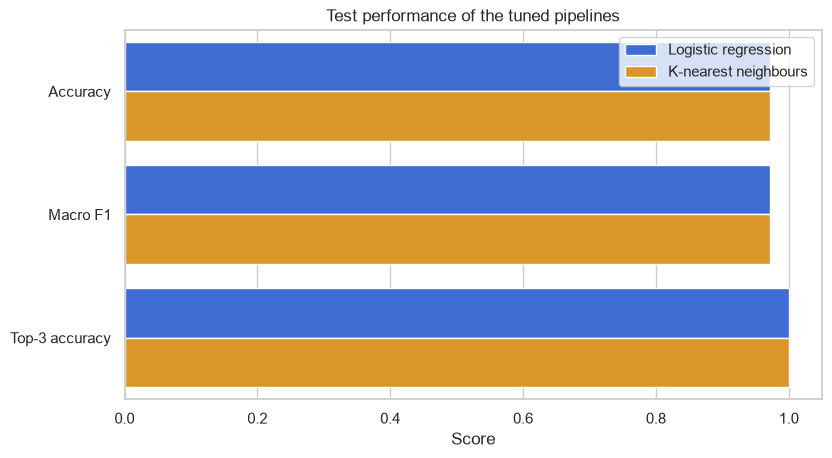

In [64]:
# Visualise accuracy, macro F1, and top-3 accuracy
metrics_for_plot = model_metrics.melt(
    id_vars="model",
    value_vars=["test_accuracy", "test_macro_f1", "test_top_3_accuracy"],
    var_name="metric",
    value_name="score",
)

metrics_for_plot["metric"] = metrics_for_plot["metric"].map({
    "test_accuracy": "Accuracy",
    "test_macro_f1": "Macro F1",
    "test_top_3_accuracy": "Top-3 accuracy",
})

plt.figure(figsize=(9, 4.8))
ax = sns.barplot(
    data=metrics_for_plot,
    x="score",
    y="metric",
    hue="model",
    palette=["#2563EB", "#F59E0B"],
)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Score")
ax.set_ylabel("")
ax.set_title("Test performance of the tuned pipelines")
ax.legend(title="")
plt.show()

### Model comparison result

**Logistic regression** has the highest test macro F1:
**97.2%**. Its test accuracy is
**97.2%**.

**K-nearest neighbours** reaches **96.4%**
macro F1. Both models reach **100% top-3 accuracy** on this simulated test
set.

The high values are expected because the profiles were generated from the
same ESCO occupation lists that define the labels. They show that the
models can recover these ESCO patterns. They must not be described as 97%
accurate on real CVs.

## 4.7 Evaluate the best model

One total score can hide weak occupations. We therefore inspect the F1
score for every occupation and the confusion matrix.

In a confusion matrix, rows are the real simulated labels and columns are
the model predictions. Values on the diagonal are correct. Values outside
the diagonal show which occupations were confused.

In [65]:
# Select the best model by test macro F1 and show each occupation's metrics
best_model_name = model_metrics.loc[0, "model"]
best_search = searches[best_model_name]
best_predictions = best_search.predict(X_test)

best_classification = classification_metrics[
    classification_metrics["model"] == best_model_name
].sort_values("f1_score", ascending=False)

print("Best model:", best_model_name)
display(best_classification)

Best model: Logistic regression


,model,occupation_name,precision,recall,f1_score,support
0,Logistic regression,artificial intelligence engineer,1.000000,1.00,1.000000,40
1,Logistic regression,data analyst,1.000000,1.00,1.000000,40
2,Logistic regression,data engineer,1.000000,1.00,1.000000,40
3,Logistic regression,data quality specialist,1.000000,1.00,1.000000,40
4,Logistic regression,data scientist,1.000000,1.00,1.000000,40
6,Logistic regression,database administrator,1.000000,1.00,1.000000,40
8,Logistic regression,database developer,1.000000,1.00,1.000000,40
7,Logistic regression,database designer,0.857143,0.90,0.878049,40
5,Logistic regression,data warehouse designer,0.894737,0.85,0.871795,40


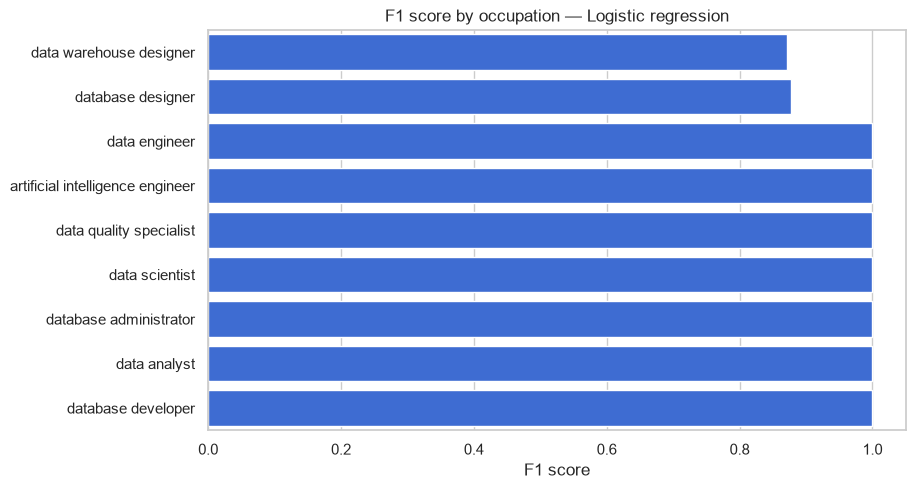

In [66]:
# Visualise the F1 score for each occupation
plt.figure(figsize=(9, 5.2))
ax = sns.barplot(
    data=best_classification.sort_values("f1_score"),
    x="f1_score",
    y="occupation_name",
    color="#2563EB",
)
ax.set_xlim(0, 1.05)
ax.set_xlabel("F1 score")
ax.set_ylabel("")
ax.set_title(f"F1 score by occupation — {best_model_name}")
plt.show()

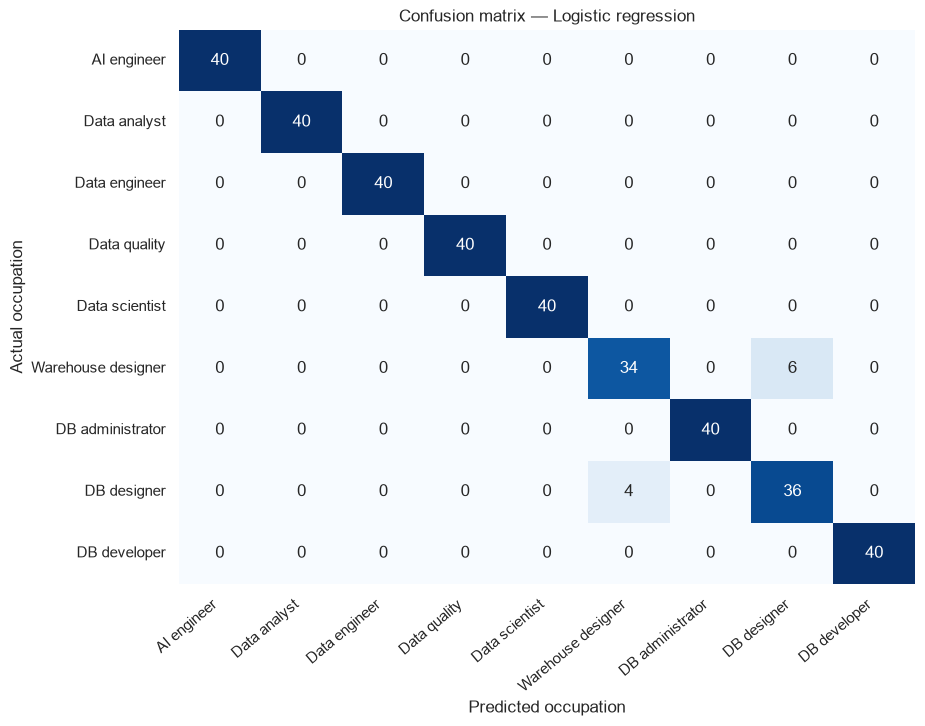

In [67]:
# Create the confusion matrix for the best model
best_matrix = confusion_matrix(
    y_test,
    best_predictions,
    labels=SELECTED_OCCUPATIONS,
)

short_labels = [
    "AI engineer",
    "Data analyst",
    "Data engineer",
    "Data quality",
    "Data scientist",
    "Warehouse designer",
    "DB administrator",
    "DB designer",
    "DB developer",
]

plt.figure(figsize=(9.5, 7.2))
ax = sns.heatmap(
    best_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=short_labels,
    yticklabels=short_labels,
)
ax.set_title(f"Confusion matrix — {best_model_name}")
ax.set_xlabel("Predicted occupation")
ax.set_ylabel("Actual occupation")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.show()

### What does the error analysis show?

The lowest F1 scores are for **data warehouse designer**
(87.2%) and
**database designer**
(87.8%).

These occupations share several database and data-management concepts, so
some partial profiles look similar. This is more useful than saying only
that the model is about 97% accurate: it tells us where the model needs
more information.

## 4.8 Is the difference between the models meaningful?

The two macro F1 scores are close. We use a paired exact test on the final
test predictions.

- **H0:** both models have the same probability of making the correct
  prediction when they disagree.
- **H1:** one model is more often correct when they disagree.

A p-value below 0.05 would give evidence of a difference. This test is about
this simulated test set only.

In [68]:
# Compare the two models with a paired exact test
logistic_predictions = searches["Logistic regression"].predict(X_test)
knn_predictions = searches["K-nearest neighbours"].predict(X_test)

logistic_only_correct = int(
    ((logistic_predictions == y_test) & (knn_predictions != y_test)).sum()
)
knn_only_correct = int(
    ((logistic_predictions != y_test) & (knn_predictions == y_test)).sum()
)

disagreements = logistic_only_correct + knn_only_correct

if disagreements == 0:
    p_value = 1.0
else:
    p_value = binomtest(
        min(logistic_only_correct, knn_only_correct),
        n=disagreements,
        p=0.5,
        alternative="two-sided",
    ).pvalue

model_test_result = pd.DataFrame({
    "logistic_only_correct": [logistic_only_correct],
    "knn_only_correct": [knn_only_correct],
    "p_value": [p_value],
    "significant_at_0_05": [p_value < 0.05],
})

display(model_test_result)

,logistic_only_correct,knn_only_correct,p_value,significant_at_0_05
0,5,5,1.0,False


### Statistical interpretation

The p-value is **0.581**. The p-value is not below 0.05, so this test does not give enough evidence that one model is better.

Logistic Regression has the higher point estimate, so we use it as the
prototype's main model. However, we should not make a strong claim that it
will always beat KNN.

## 4.9 Explain one recommendation

A recommendation system should not return only a job name. We first inspect
the strongest positive Logistic Regression signals for `data scientist`.
Then we test one example profile with 14 concepts and show:

- the ranked model score;
- how many essential concepts are shared;
- the names of the shared concepts;
- how many essential concepts are still missing.

The model weight is a signal inside this model. It is not a universal skill
ranking and it is not a hiring rule.

In [69]:
# Extract the ten strongest Logistic Regression signals for every occupation
logistic_pipeline = searches["Logistic regression"].best_estimator_
vectorizer = logistic_pipeline.named_steps["tfidf"]
logistic_model = logistic_pipeline.named_steps["model"]
feature_names = vectorizer.get_feature_names_out()

token_details = (
    selected_relations[["skill_token", "skill_uri", "skill_name", "skill_type"]]
    .drop_duplicates(subset="skill_token")
    .set_index("skill_token")
)

top_concept_rows = []
for class_number, occupation in enumerate(logistic_model.classes_):
    top_positions = np.argsort(logistic_model.coef_[class_number])[::-1][:10]

    for rank, position in enumerate(top_positions, start=1):
        token = feature_names[position]
        top_concept_rows.append({
            "occupation_name": occupation,
            "rank": rank,
            "skill_uri": token_details.loc[token, "skill_uri"],
            "skill_name": token_details.loc[token, "skill_name"],
            "skill_type": token_details.loc[token, "skill_type"],
            "model_weight": logistic_model.coef_[class_number, position],
        })

top_model_concepts = pd.DataFrame(top_concept_rows)
data_scientist_top_concepts = top_model_concepts[
    top_model_concepts["occupation_name"] == "data scientist"
]

display(data_scientist_top_concepts)

,occupation_name,rank,skill_uri,skill_name,skill_type,model_weight
40,data scientist,1,http://data.europa.eu/esco/skill/f6ac6241-adb2...,empirical analysis,knowledge,3.735523
41,data scientist,2,http://data.europa.eu/esco/skill/68ef0e4d-5542...,statistical modeling techniques,knowledge,3.392764
42,data scientist,3,http://data.europa.eu/esco/skill/da930e2f-6047...,manage open publications,skill/competence,3.309020
43,data scientist,4,http://data.europa.eu/esco/skill/9a58cd26-58eb...,think abstractly,skill/competence,3.230987
44,data scientist,5,http://data.europa.eu/esco/skill/518dc04d-092d...,manage intellectual property rights,skill/competence,3.211155
45,data scientist,6,http://data.europa.eu/esco/skill/4134622c-c3fb...,demonstrate disciplinary expertise,skill/competence,3.172590
46,data scientist,7,http://data.europa.eu/esco/skill/979cf728-896f...,publish academic research,skill/competence,3.167132
47,data scientist,8,http://data.europa.eu/esco/skill/00b9a3aa-7070...,draft scientific or academic papers and techni...,skill/competence,3.161550
48,data scientist,9,http://data.europa.eu/esco/skill/988f4ac3-a37c...,promote the transfer of knowledge,skill/competence,3.155748
49,data scientist,10,http://data.europa.eu/esco/skill/39f67488-cfd3...,evaluate research activities,skill/competence,3.086425


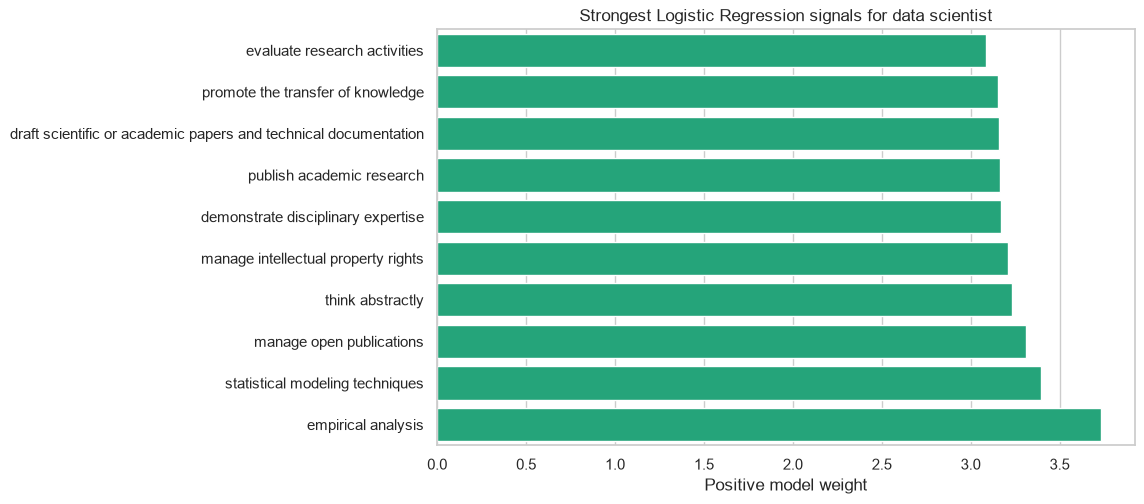

In [70]:
# Visualise the strongest positive signals for data scientist
plt.figure(figsize=(9, 5.4))
ax = sns.barplot(
    data=data_scientist_top_concepts.sort_values("model_weight"),
    x="model_weight",
    y="skill_name",
    color="#10B981",
)
ax.set_xlabel("Positive model weight")
ax.set_ylabel("")
ax.set_title("Strongest Logistic Regression signals for data scientist")
plt.show()

In [71]:
# Define one example profile with 14 ESCO concepts
example_skill_names = [
    "Python (computer programming)",
    "statistics",
    "data visualisation software",
    "perform data cleansing",
    "utilise machine learning",
    "data ethics",
    "collect ICT data",
    "execute analytical mathematical calculations",
    "build recommender systems",
    "perform scientific research",
    "report analysis results",
    "interpret current data",
    "data mining",
    "mathematical modelling",
]

display(pd.DataFrame({"example_skill": example_skill_names}))

,example_skill
0,Python (computer programming)
1,statistics
2,data visualisation software
3,perform data cleansing
4,utilise machine learning
5,data ethics
6,collect ICT data
7,execute analytical mathematical calculations
8,build recommender systems
9,perform scientific research


In [72]:
# Rank occupations and add a simple shared-concept explanation
name_to_token = (
    selected_relations[["skill_name", "skill_token"]]
    .drop_duplicates(subset="skill_name")
    .set_index("skill_name")["skill_token"]
    .to_dict()
)
name_to_uri = (
    selected_relations[["skill_name", "skill_uri"]]
    .drop_duplicates(subset="skill_name")
    .set_index("skill_name")["skill_uri"]
    .to_dict()
)

example_tokens = [name_to_token[name.lower()] for name in example_skill_names]
example_text = " ".join(example_tokens)

probabilities = best_search.predict_proba([example_text])[0]
classes = best_search.best_estimator_.classes_

ranking = pd.DataFrame({
    "occupation_name": classes,
    "model_score": probabilities,
}).sort_values("model_score", ascending=False)
ranking["rank"] = range(1, len(ranking) + 1)

profile_uris = {name_to_uri[name.lower()] for name in example_skill_names}
explanation_rows = []

for recommendation in ranking.itertuples():
    essential = selected_relations[
        (selected_relations["occupation_name"] == recommendation.occupation_name)
        & (selected_relations["relation_type"] == "essential")
    ]
    essential_uris = set(essential["skill_uri"])
    matched_uris = essential_uris & profile_uris
    matched_names = sorted(
        essential.loc[
            essential["skill_uri"].isin(matched_uris), "skill_name"
        ].unique()
    )

    explanation_rows.append({
        "rank": recommendation.rank,
        "occupation_name": recommendation.occupation_name,
        "model_score": recommendation.model_score,
        "matched_essential_concepts": len(matched_uris),
        "total_essential_concepts": len(essential_uris),
        "essential_coverage": len(matched_uris) / len(essential_uris),
        "missing_essential_concepts": len(essential_uris - matched_uris),
        "matched_concepts": (
            "; ".join(matched_names)
            if matched_names
            else "No shared essential concepts in this example."
        ),
    })

example_recommendations = pd.DataFrame(explanation_rows)
display(example_recommendations.head(3))

,rank,occupation_name,model_score,matched_essential_concepts,total_essential_concepts,essential_coverage,missing_essential_concepts,matched_concepts
0,1,data scientist,0.436779,12,63,0.190476,51,build recommender systems; collect ict data; d...
1,2,data analyst,0.301746,8,36,0.222222,28,collect ict data; data ethics; data mining; da...
2,3,data quality specialist,0.059339,3,20,0.150000,17,data ethics; perform data cleansing; report an...


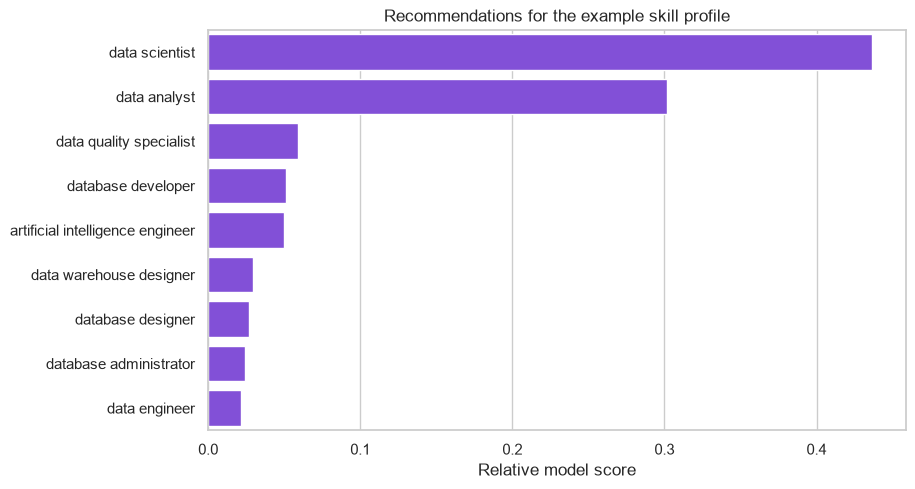

In [73]:
# Visualise all recommendation scores for the example profile
plt.figure(figsize=(9, 5.2))
ax = sns.barplot(
    data=example_recommendations,
    x="model_score",
    y="occupation_name",
    color="#7C3AED",
)
ax.set_xlabel("Relative model score")
ax.set_ylabel("")
ax.set_title("Recommendations for the example skill profile")
plt.show()

### Example interpretation

The first recommendation is **data scientist** with
a relative model score of **43.7%**. The
second is **data analyst**
(30.2%), followed by
**data quality specialist**
(5.9%).

These scores compare the nine classes inside this fitted model. They are not
a person's probability of success and they are not calibrated hiring
probabilities. The shared-concept columns give a more understandable reason
for each recommendation.

## 4.10 Export a Power BI data model

Power BI works well with a star schema. We create small dimension tables for
occupations, concepts, and models. Fact tables contain relations, metrics,
predictions, and recommendation results.

Main relationships:

- `dim_occupation[occupation_id]` →
  `fact_occupation_concept[occupation_id]`
- `dim_concept[concept_id]` →
  `fact_occupation_concept[concept_id]`
- `dim_model[model_id]` → model result tables

The relationship file lists the recommended Power BI connections. Use
single-direction filters from each dimension to each fact table.

In [74]:
# Create the occupation, concept, and relation tables for Power BI
dim_occupation = pd.DataFrame({
    "occupation_id": range(1, len(SELECTED_OCCUPATIONS) + 1),
    "occupation_name": SELECTED_OCCUPATIONS,
})
dim_occupation["is_data_scientist"] = (
    dim_occupation["occupation_name"] == "data scientist"
)

dim_concept = (
    selected_relations[[
        "skill_uri",
        "skill_name",
        "skill_type",
        "skill_description",
    ]]
    .drop_duplicates(subset="skill_uri")
    .sort_values("skill_name")
    .reset_index(drop=True)
)
dim_concept.insert(0, "concept_id", range(1, len(dim_concept) + 1))

fact_occupation_concept = selected_relations[
    ["occupation_name", "skill_uri", "relation_type"]
].copy()
fact_occupation_concept = fact_occupation_concept.merge(
    dim_occupation[["occupation_id", "occupation_name"]],
    on="occupation_name",
    how="left",
).merge(
    dim_concept[["concept_id", "skill_uri"]],
    on="skill_uri",
    how="left",
)
fact_occupation_concept = fact_occupation_concept[
    ["occupation_id", "concept_id", "relation_type"]
].drop_duplicates()

print("Occupations:", len(dim_occupation))
print("Concepts:", len(dim_concept))
print("Occupation-concept relations:", len(fact_occupation_concept))

Occupations: 9
Concepts: 293
Occupation-concept relations: 717


In [75]:
# Create model-result tables and the example recommendation tables
dim_model = pd.DataFrame({
    "model_id": range(1, len(model_metrics) + 1),
    "model": model_metrics["model"],
})

fact_model_metrics = model_metrics.merge(dim_model, on="model", how="left")

fact_classification_metrics = (
    classification_metrics
    .merge(dim_model, on="model", how="left")
    .merge(dim_occupation, on="occupation_name", how="left")
)

fact_confusion_matrix = confusion_data.merge(
    dim_model, on="model", how="left"
)
fact_predictions = test_predictions.merge(
    dim_model, on="model", how="left"
)

top_model_concepts_export = (
    top_model_concepts
    .merge(
        dim_occupation[["occupation_id", "occupation_name"]],
        on="occupation_name",
        how="left",
    )
    .merge(
        dim_concept[["concept_id", "skill_uri"]],
        on="skill_uri",
        how="left",
    )
)

example_recommendations_export = example_recommendations.merge(
    dim_occupation[["occupation_id", "occupation_name"]],
    on="occupation_name",
    how="left",
)

example_profile_skills = pd.DataFrame({
    "skill_name": [name.lower() for name in example_skill_names]
}).merge(
    dim_concept[["concept_id", "skill_name", "skill_type"]],
    on="skill_name",
    how="left",
)

In [76]:
# Describe the recommended Power BI relationships and important columns
powerbi_relationships = pd.DataFrame([
    ["dim_occupation", "occupation_id", "fact_occupation_concept", "occupation_id", "one-to-many"],
    ["dim_concept", "concept_id", "fact_occupation_concept", "concept_id", "one-to-many"],
    ["dim_model", "model_id", "fact_model_metrics", "model_id", "one-to-many"],
    ["dim_model", "model_id", "fact_classification_metrics", "model_id", "one-to-many"],
    ["dim_occupation", "occupation_id", "fact_classification_metrics", "occupation_id", "one-to-many"],
    ["dim_occupation", "occupation_id", "example_recommendations", "occupation_id", "one-to-many"],
], columns=[
    "from_table", "from_column", "to_table", "to_column", "cardinality"
])

data_dictionary = pd.DataFrame([
    ["dim_occupation", "occupation_id", "Unique key for an occupation."],
    ["dim_concept", "concept_id", "Unique key for an ESCO concept."],
    ["dim_concept", "skill_description", "Description supplied by ESCO."],
    ["fact_occupation_concept", "relation_type", "Essential or optional in ESCO."],
    ["fact_model_metrics", "test_macro_f1", "Average F1 across nine occupations."],
    ["fact_model_metrics", "test_top_3_accuracy", "Correct job is in the first three results."],
    ["fact_classification_metrics", "f1_score", "F1 for one occupation."],
    ["fact_confusion_matrix", "number_of_profiles", "Profiles for one actual/predicted pair."],
    ["top_model_concepts", "model_weight", "Model signal, not a hiring importance score."],
    ["example_recommendations", "model_score", "Relative score, not a suitability probability."],
], columns=["table_name", "column_name", "meaning"])

display(powerbi_relationships)

,from_table,from_column,to_table,to_column,cardinality
0,dim_occupation,occupation_id,fact_occupation_concept,occupation_id,one-to-many
1,dim_concept,concept_id,fact_occupation_concept,concept_id,one-to-many
2,dim_model,model_id,fact_model_metrics,model_id,one-to-many
3,dim_model,model_id,fact_classification_metrics,model_id,one-to-many
4,dim_occupation,occupation_id,fact_classification_metrics,occupation_id,one-to-many
5,dim_occupation,occupation_id,example_recommendations,occupation_id,one-to-many


In [77]:
# Export all Power BI tables as CSV files
EXPORT_DIR = Path("powerbi_exports")
EXPORT_DIR.mkdir(exist_ok=True)

export_tables = {
    "dim_occupation.csv": dim_occupation,
    "dim_concept.csv": dim_concept,
    "fact_occupation_concept.csv": fact_occupation_concept,
    "dim_model.csv": dim_model,
    "fact_model_metrics.csv": fact_model_metrics,
    "fact_classification_metrics.csv": fact_classification_metrics,
    "fact_confusion_matrix.csv": fact_confusion_matrix,
    "fact_test_predictions.csv": fact_predictions,
    "top_model_concepts.csv": top_model_concepts_export,
    "example_recommendations.csv": example_recommendations_export,
    "example_profile_skills.csv": example_profile_skills,
    "powerbi_relationships.csv": powerbi_relationships,
    "data_dictionary.csv": data_dictionary,
}

for filename, table in export_tables.items():
    table.to_csv(EXPORT_DIR / filename, index=False)

export_summary = pd.DataFrame({
    "file": list(export_tables.keys()),
    "rows": [len(table) for table in export_tables.values()],
    "columns": [table.shape[1] for table in export_tables.values()],
})

display(export_summary)

,file,rows,columns
0,dim_occupation.csv,9,3
1,dim_concept.csv,293,5
2,fact_occupation_concept.csv,717,3
3,dim_model.csv,2,2
4,fact_model_metrics.csv,2,7
5,fact_classification_metrics.csv,18,9
6,fact_confusion_matrix.csv,162,5
7,fact_test_predictions.csv,720,6
8,top_model_concepts.csv,90,8
9,example_recommendations.csv,9,9


### Suggested Power BI report pages

**Page 1 — Occupation overview**

- Cards: number of occupations, concepts, essential relations, optional relations
- Stacked bar: essential and optional concepts by occupation
- Slicers: occupation, relation type, and concept type
- Detail table: concept name and description

**Page 2 — Model performance**

- Cards: accuracy, macro F1, and top-3 accuracy
- Clustered bars: metrics by model
- Heatmap or matrix: actual versus predicted occupation
- Bar chart: F1 score by occupation

**Page 3 — Recommendation explorer**

- Bar chart: model score by recommended occupation
- Cards: shared essential concepts and missing essential concepts
- Table: matched concept names
- Bar chart: strongest model signals by occupation

Import the folder `powerbi_exports`, then create the relationships listed in
`powerbi_relationships.csv`.

## 4.11 Final project conclusion

### Main findings

The project started with raw ESCO occupation and skill data. We cleaned the
data, explored its structure, selected nine important data and AI
occupations, compared their concepts, measured similarity, tested research
questions, and built a recommendation prototype.

In Part 4, **Logistic regression** produced the best point estimate. It
reached **97.2% test accuracy**,
**97.2% macro F1**, and
**100.0% top-3 accuracy** on 360 simulated
test profiles.

The second model, **K-nearest neighbours**, reached
**96.4% macro F1**. The paired exact test gave
**p = 0.581**. Therefore, the observed difference is not
strong enough to claim that one model will always be better.

The main errors came from occupations with similar data-management and
database concepts. This shows why a useful system should return several
possible occupations and explain the shared and missing concepts.

### What the result does not prove

These are simulated profiles made from ESCO itself. The results prove that
the pipelines can learn the patterns used to generate the profiles. They do
**not** prove the same performance on real CVs, real vacancies, or real
people.

### Ethical use

This model should support exploration, not decide who gets an interview or
a job. A real system would need informed consent, data minimisation, secure
storage, human review, clear explanations, bias and fairness checks, and
compliance with privacy law such as the GDPR. Sensitive personal data
should not be used as model features.

ESCO can also be incomplete or out of date. A missing concept does not mean
that a person lacks ability. Model scores must never be presented as talent,
suitability, or human worth.

# End of the SkillBridge project

The notebook, model result tables, and Power BI-ready exports now form one
complete end-to-end portfolio project: data preparation, SQL analysis,
statistics, machine learning, explanation, ethics, and business
intelligence.

# Interactive occupation recommender

Enter one or more ESCO skill names, separated by commas. The recommender ranks
the nine occupations used in this project.

The **relative model score** compares only these nine occupations and totals
100% across them. It is not the probability of getting a job. The **essential
skill coverage** shows how many of the occupation's ESCO essential skills were
included in the entered profile. For a more useful result, enter several skills
rather than only one.

In [78]:
# Create a reusable occupation recommender for entered ESCO skill names
from difflib import get_close_matches


def recommend_occupations(skill_names, top_n=5, show_chart=True):
    """Rank the project's nine occupations for one or more ESCO skill names."""

    # Accept either a comma-separated string or a Python list of skill names
    if isinstance(skill_names, str):
        entered_skills = [
            skill.strip().casefold()
            for skill in skill_names.split(",")
            if skill.strip()
        ]
    else:
        entered_skills = [
            str(skill).strip().casefold()
            for skill in skill_names
            if str(skill).strip()
        ]

    # Remove repeated entries while keeping their original order
    entered_skills = list(dict.fromkeys(entered_skills))
    if not entered_skills:
        raise ValueError("Enter at least one skill name.")

    # Build a case-insensitive ESCO name lookup table
    skill_lookup = selected_relations[
        ["skill_name", "skill_token", "skill_uri"]
    ].drop_duplicates().copy()
    skill_lookup["skill_key"] = skill_lookup["skill_name"].str.casefold()
    skill_lookup = skill_lookup.drop_duplicates("skill_key").set_index("skill_key")

    available_skills = skill_lookup.index.tolist()
    matched_skills = [
        skill for skill in entered_skills if skill in skill_lookup.index
    ]
    unknown_skills = [
        skill for skill in entered_skills if skill not in skill_lookup.index
    ]

    # Show suggestions when an entered name is not an exact ESCO name
    if unknown_skills:
        print("Skills not recognised:")
        for skill in unknown_skills:
            suggestions = get_close_matches(
                skill,
                available_skills,
                n=3,
                cutoff=0.55,
            )
            suggestion_text = ", ".join(suggestions) if suggestions else "no close match"
            print(f"- {skill}: {suggestion_text}")

    if not matched_skills:
        raise ValueError(
            "None of the entered names matched an ESCO skill used by the model."
        )

    # Convert the recognised skill names into the tokens used during training
    skill_tokens = [
        skill_lookup.at[skill, "skill_token"]
        for skill in matched_skills
    ]
    profile_text = " ".join(skill_tokens)

    # Calculate one relative model score for every occupation
    model_scores = best_search.predict_proba([profile_text])[0]
    occupations = best_search.best_estimator_.classes_
    profile_uris = {
        skill_lookup.at[skill, "skill_uri"]
        for skill in matched_skills
    }

    result_rows = []
    for occupation, model_score in zip(occupations, model_scores):
        essential = selected_relations[
            (selected_relations["occupation_name"] == occupation)
            & (selected_relations["relation_type"] == "essential")
        ]
        essential_uris = set(essential["skill_uri"])
        matched_uris = essential_uris.intersection(profile_uris)
        matched_names = sorted(
            essential.loc[
                essential["skill_uri"].isin(matched_uris),
                "skill_name",
            ].unique()
        )

        coverage = (
            100 * len(matched_uris) / len(essential_uris)
            if essential_uris
            else 0.0
        )

        result_rows.append({
            "occupation": occupation,
            "relative_model_score_pct": 100 * model_score,
            "essential_skill_coverage_pct": coverage,
            "matched_essential_skills": len(matched_uris),
            "matched_skill_names": "; ".join(matched_names) or "None",
        })

    results = (
        pd.DataFrame(result_rows)
        .sort_values("relative_model_score_pct", ascending=False)
        .reset_index(drop=True)
    )
    results.insert(0, "rank", range(1, len(results) + 1))
    top_n = max(1, min(int(top_n), len(results)))
    top_results = results.head(top_n).copy()

    print("Recognised skills:", ", ".join(matched_skills))
    print(
        "Important: the model score is relative to the nine occupations; "
        "it is not a job-success probability."
    )
    display_table = top_results.copy()
    display_table["relative_model_score_pct"] = display_table[
        "relative_model_score_pct"
    ].map(lambda value: f"{value:.1f}%")
    display_table["essential_skill_coverage_pct"] = display_table[
        "essential_skill_coverage_pct"
    ].map(lambda value: f"{value:.1f}%")
    display(display_table)

    if show_chart:
        chart_data = top_results.sort_values(
            "relative_model_score_pct",
            ascending=True,
        )
        plt.figure(figsize=(9, 4.8))
        ax = sns.barplot(
            data=chart_data,
            x="relative_model_score_pct",
            y="occupation",
            color="#2563EB",
        )
        ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
        ax.set_xlabel("Relative model score")
        ax.set_ylabel("")
        ax.set_title("Closest occupations for the entered ESCO skills")
        ax.set_xlim(0, max(chart_data["relative_model_score_pct"].max() * 1.18, 10))
        plt.tight_layout()
        plt.show()

    return results


In [79]:
# Show all available ESCO skill names
available_skills = sorted(
    selected_relations["skill_name"]
    .dropna()
    .drop_duplicates()
)

for skill in available_skills:
    print(skill)

abap
address problems critically
administer ict system
agile project management
ajax
ajax framework
algorithms
analyse big data
analyse business requirements
analyse pipeline database information
apl
apply blended learning
apply company policies
apply for research funding
apply ict systems theory
apply information security policies
apply research ethics and scientific integrity principles in research activities
apply statistical analysis techniques
apply systemic design thinking
apply technical communication skills
artificial neural networks
asp.net
assembly (computer programming)
assess ict knowledge
balance database resources
build business relationships
build predictive models
build recommender systems
business analytics
business intelligence
business process modelling
business processes
c#
c++
ca datacom/db
cloud technologies
cobol
coffeescript
collect customer feedback on applications
collect ict data
common lisp
communicate with a non-scientific audience
computational biology
com

In [ ]:
# Enter ESCO skill names separated by commas, then run this cell
# Example: statistics, data mining, perform data cleansing
entered_skill_text = input("Enter your skills, separated by commas: ")

job_recommendations = recommend_occupations(
    entered_skill_text,
    top_n=5,
    show_chart=True,
)
